# **New York City Yellow Taxi Data From ROMA Agrawal**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [ ]:
# Import warnings



In [1]:
# Import the libraries you will be using for analysis

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.9.2
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('C:\Users\admin\Downloads\fhvhv_tripdata_2023-01.parquet.parquet')`

In [5]:
df1 = pd.read_parquet("NYCC/yellow_tripdata_2023-01.parquet")
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [31]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [33]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
import os
os.chdir('NYC')
file_list = os.listdir()


# Initialize empty DataFrame for the final combined sample
sampled_data = pd.DataFrame()

# Process each file
for file in file_path:
    df = pd.read_parquet(file, engine='pyarrow')  # Specify the engine
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

    # Group by day and hour, sample 5% from each hour
    for day, day_data in df.groupby(df['tpep_pickup_datetime'].dt.date):
        for hour, hour_data in day_data.groupby(day_data['tpep_pickup_datetime'].dt.hour):
            sample = hour_data.sample(frac=0.01, random_state=42)
            sampled_data = pd.concat([sampled_data, sample], ignore_index=True)



After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [25]:
#sampled_data.info()
print("Sampled data shape:", sampled_data.shape)
# Store the df in csv/parquet
#df.to_parquet('\NYCC')

Sampled data shape: (383116, 20)


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [31]:
# Load the new data file

df = pd.read_csv(r"sampled_yellow_tripdata_2023_1.csv")

In [33]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,2,2023-06-01 00:35:13,2023-06-01 01:12:51,1.0,13.09,1.0,N,142,14,1,54.8,1.0,0.5,13.27,6.55,1.0,79.62,2.5,0.0,NaN
1,2,2023-06-01 00:43:37,2023-06-01 00:48:26,1.0,1.59,1.0,N,249,107,1,8.6,1.0,0.5,2.72,0.00,1.0,16.32,2.5,0.0,NaN
2,2,2023-06-01 00:13:18,2023-06-01 00:19:43,1.0,1.67,1.0,N,114,79,1,9.3,1.0,0.5,2.86,0.00,1.0,17.16,2.5,0.0,NaN
3,2,2023-06-01 00:17:04,2023-06-01 00:27:14,1.0,3.24,1.0,N,170,263,1,14.9,1.0,0.5,3.98,0.00,1.0,23.88,2.5,0.0,NaN
4,2,2023-06-01 00:20:44,2023-06-01 00:39:33,1.0,4.34,1.0,N,230,7,2,21.9,1.0,0.5,0.00,0.00,1.0,26.90,2.5,0.0,NaN


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383116 entries, 0 to 383115
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               383116 non-null  int64  
 1   tpep_pickup_datetime   383116 non-null  object 
 2   tpep_dropoff_datetime  383116 non-null  object 
 3   passenger_count        370219 non-null  float64
 4   trip_distance          383116 non-null  float64
 5   RatecodeID             370219 non-null  float64
 6   store_and_fwd_flag     370219 non-null  object 
 7   PULocationID           383116 non-null  int64  
 8   DOLocationID           383116 non-null  int64  
 9   payment_type           383116 non-null  int64  
 10  fare_amount            383116 non-null  float64
 11  extra                  383116 non-null  float64
 12  mta_tax                383116 non-null  float64
 13  tip_amount             383116 non-null  float64
 14  tolls_amount           383116 non-nu

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [43]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop=True, inplace=True)


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [37]:
# Combine the two airport fee columns
if 'Airport_fee' in df.columns and 'airport_fee' in df.columns:
    # Step 1: Fill missing or zero Airport_fee where airport_fee is ±1.25
    condition_fill = ((df['Airport_fee'].isna()) | (df['Airport_fee'] == 0)) & \
                     (df['airport_fee'].isin([1.25, -1.25]))
    df.loc[condition_fill, 'Airport_fee'] = 1.25

    # Step 2: Replace -1.25 in Airport_fee with 1.25
    df.loc[df['Airport_fee'] == -1.25, 'Airport_fee'] = 1.25

    # Step 3: Drop the redundant airport_fee column
    df.drop(columns=['airport_fee'], inplace=True)

    print("'Airport_fee' corrected and 'airport_fee' dropped.")
else:
    print("One or both columns 'Airport_fee' or 'airport_fee' are missing.")

'Airport_fee' corrected and 'airport_fee' dropped.


**2.1.3** ix columns with negative (monetary) values

In [39]:
df.head()
#df.info()
# check where values of fare amount are negative

df['index_col'] = df.index

df = df[['index_col'] + [col for col in df.columns if col != 'index_col']]
print("✅ Added 'index_col' to the DataFrame.")


✅ Added 'index_col' to the DataFrame.


Did you notice something different in the `RatecodeID` column for above records?

In [41]:
# Analyse RatecodeID for the negative fare amounts

# Filter rows with negative fare amounts
negative_fares = df[df['fare_amount'] < 0]

# Count how many negative fares fall under each RatecodeID
ratecode_negative_fares = negative_fares['RatecodeID'].value_counts(dropna=False).sort_index()

# Show summary
print("Count of negative fare_amounts by RatecodeID:\n")
print(ratecode_negative_fares)

# Optional: Show some sample rows for inspection
print("\n Sample rows with negative fare amounts:")
print(negative_fares[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'RatecodeID', 'fare_amount']].head())

Count of negative fare_amounts by RatecodeID:

RatecodeID
1.0    3354
2.0     262
3.0      44
4.0      23
5.0      66
NaN      64
Name: count, dtype: int64

 Sample rows with negative fare amounts:
    tpep_pickup_datetime tpep_dropoff_datetime  RatecodeID  fare_amount
5    2023-06-01 00:26:05   2023-06-01 00:26:21         1.0         -3.0
47   2023-06-01 05:53:58   2023-06-01 06:32:47         1.0        -73.0
49   2023-06-01 05:58:23   2023-06-01 05:58:49         1.0         -3.0
95   2023-06-01 07:18:27   2023-06-01 07:19:21         1.0         -3.0
102  2023-06-01 07:50:46   2023-06-01 08:09:15         1.0        -18.4


In [43]:
# Replace negative fare_amounts with their absolute values
df['fare_amount'] = df['fare_amount'].abs()

print("All negative 'fare_amount' values have been converted to positive.")

# Find which columns have negative values

# Find numeric columns that contain any negative values
#negative_columns = df.select_dtypes(include='number').columns[
#    (df.select_dtypes(include='number') < 0).any()
#]

# Display the list and how many negatives each has
#for col in negative_columns:
#    count_neg = (df[col] < 0).sum()
#    print(f"Column '{col}' has {count_neg} negative values.")

All negative 'fare_amount' values have been converted to positive.


In [43]:
# Replace negative fare_amounts with their absolute values
df['fare_amount'] = df['fare_amount'].abs()

print("All negative 'fare_amount' values have been converted to positive.")


All negative 'fare_amount' values have been converted to positive.


In [43]:
# Replace negative fare_amounts with their absolute values
df['fare_amount'] = df['fare_amount'].abs()

print("All negative 'fare_amount' values have been converted to positive.")

# Find which columns have negative values

# Find numeric columns that contain any negative values
#negative_columns = df.select_dtypes(include='number').columns[
#    (df.select_dtypes(include='number') < 0).any()
#]

# Display the list and how many negatives each has
#for col in negative_columns:
#    count_neg = (df[col] < 0).sum()
#    print(f"Column '{col}' has {count_neg} negative values.")

All negative 'fare_amount' values have been converted to positive.


In [47]:
negative_fare_count = (df['fare_amount'] < 0).sum()
print(f"Number of negative fare_amount values: {negative_fare_count}")

Number of negative fare_amount values: 0


In [49]:

# Find which columns have negative values

# Find numeric columns that contain any negative values
negative_columns = df.select_dtypes(include='number').columns[
    (df.select_dtypes(include='number') < 0).any()
]

# Display the list and how many negatives each has
for col in negative_columns:
    count_neg = (df[col] < 0).sum()
    print(f"Column '{col}' has {count_neg} negative values.")

Column 'extra' has 1923 negative values.
Column 'mta_tax' has 3663 negative values.
Column 'tip_amount' has 17 negative values.
Column 'tolls_amount' has 243 negative values.
Column 'improvement_surcharge' has 3771 negative values.
Column 'total_amount' has 3774 negative values.
Column 'congestion_surcharge' has 3037 negative values.
Column 'Airport_fee' has 397 negative values.


In [51]:
# Save the final sampled DataFrame to CSV
output_csv = "sampled_yellow_tripdata_2023_4.csv"
df.to_csv(output_csv, index=False)

# fix these negative values



### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [55]:
# Find the proportion of missing values in each column

missing_proportion = df.isnull().mean().sort_values(ascending=False)

# Display as percentage
missing_percent = (missing_proportion * 100).round(2)

print("Proportion of missing values in each column (%):\n")
print(missing_percent[missing_percent > 0]) 

Proportion of missing values in each column (%):

Airport_fee             10.48
congestion_surcharge     3.37
passenger_count          3.37
RatecodeID               3.37
store_and_fwd_flag       3.37
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [59]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
null_passenger_rows = df[df['passenger_count'].isnull()]
print(f"Rows with null 'passenger_count': {len(null_passenger_rows)}")
print(null_passenger_rows[['index_col', 'tpep_pickup_datetime', 'fare_amount', 'passenger_count']].head())

Rows with null 'passenger_count': 12897
    index_col tpep_pickup_datetime  fare_amount  passenger_count
13         13  2023-06-01 00:13:39        13.50              NaN
22         22  2023-06-01 01:06:00        12.74              NaN
29         29  2023-06-01 01:30:21        27.78              NaN
54         54  2023-06-01 06:32:00        29.37              NaN
90         90  2023-06-01 07:22:00        29.48              NaN


In [63]:
passenger_mode = df['passenger_count'].mode()[0]

# Fill missing values with mode
df['passenger_count'].fillna(passenger_mode, inplace=True)

print(f"Filled missing 'passenger_count' with mode value: {passenger_mode}")

Filled missing 'passenger_count' with mode value: 1.0


/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_68100/4230072297.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['passenger_count'].fillna(passenger_mode, inplace=True)


Did you find zeroes in passenger_count? Handle these.

In [67]:
null_passenger_rows = df[df['passenger_count'].isnull()]
print(f"Rows with null 'passenger_count': {len(null_passenger_rows)}")

Rows with null 'passenger_count': 0


In [69]:
#Did you find zeroes in passenger_count? Handle these.

zero_passengers = df[df['passenger_count'] == 0]
print(f"Rows with 'passenger_count' == 0: {len(zero_passengers)}")
print(zero_passengers[['index_col', 'tpep_pickup_datetime', 'fare_amount', 'passenger_count']].head())

Rows with 'passenger_count' == 0: 5814
     index_col tpep_pickup_datetime  fare_amount  passenger_count
58          58  2023-06-01 06:00:42         15.6              0.0
68          68  2023-06-01 06:16:59          4.4              0.0
91          91  2023-06-01 07:31:39         19.8              0.0
112        112  2023-06-01 08:11:16         15.6              0.0
132        132  2023-06-01 08:43:47         15.6              0.0


In [71]:
# Calculate the mode again (if not already done earlier)
passenger_mode = df['passenger_count'].mode()[0]

# Replace 0 with mode
df.loc[df['passenger_count'] == 0, 'passenger_count'] = passenger_mode

print(f"Replaced 'passenger_count' == 0 with mode value: {passenger_mode}")

Replaced 'passenger_count' == 0 with mode value: 1.0


In [ ]:
# Handle missing values in RatecodeID and Fix missing values in 'RatecodeID'

In [74]:

# Count and preview missing values
missing_ratecode = df['RatecodeID'].isnull().sum()
print(f"Missing 'RatecodeID' entries: {missing_ratecode}")

if missing_ratecode > 0:
    print(df[df['RatecodeID'].isnull()][['index_col', 'tpep_pickup_datetime', 'fare_amount', 'RatecodeID']].head())

Missing 'RatecodeID' entries: 12897
    index_col tpep_pickup_datetime  fare_amount  RatecodeID
13         13  2023-06-01 00:13:39        13.50         NaN
22         22  2023-06-01 01:06:00        12.74         NaN
29         29  2023-06-01 01:30:21        27.78         NaN
54         54  2023-06-01 06:32:00        29.37         NaN
90         90  2023-06-01 07:22:00        29.48         NaN


In [76]:
ratecode_mode = df['RatecodeID'].mode()[0]

# Fill NaNs with mode
df['RatecodeID'].fillna(ratecode_mode, inplace=True)

print(f"Filled missing 'RatecodeID' with mode value: {ratecode_mode}")

Filled missing 'RatecodeID' with mode value: 1.0


/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_68100/1772683756.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['RatecodeID'].fillna(ratecode_mode, inplace=True)


In [78]:
missing_ratecode = df['RatecodeID'].isnull().sum()
print(f"Missing 'RatecodeID' entries: {missing_ratecode}")

Missing 'RatecodeID' entries: 0


#Impute NaN in `congestion_surcharge`

In [80]:
# handle null values in congestion_surcharge

missing_congestion = df['congestion_surcharge'].isnull().sum()
print(f"Missing 'congestion_surcharge' values: {missing_congestion}")

if missing_congestion > 0:
    print(df[df['congestion_surcharge'].isnull()][['index_col', 'tpep_pickup_datetime', 'fare_amount', 'congestion_surcharge']].head())

Missing 'congestion_surcharge' values: 12897
    index_col tpep_pickup_datetime  fare_amount  congestion_surcharge
13         13  2023-06-01 00:13:39        13.50                   NaN
22         22  2023-06-01 01:06:00        12.74                   NaN
29         29  2023-06-01 01:30:21        27.78                   NaN
54         54  2023-06-01 06:32:00        29.37                   NaN
90         90  2023-06-01 07:22:00        29.48                   NaN


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [82]:
# Get the most frequent congestion surcharge value
congestion_mode = df['congestion_surcharge'].mode()[0]

# Fill NaNs with mode
df['congestion_surcharge'].fillna(congestion_mode, inplace=True)

print(f"Filled missing 'congestion_surcharge' with mode value: {congestion_mode}")


# Handle any remaining missing values



Filled missing 'congestion_surcharge' with mode value: 2.5


/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_68100/4197380895.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['congestion_surcharge'].fillna(congestion_mode, inplace=True)


In [84]:
missing_proportion = df.isnull().mean().sort_values(ascending=False)

# Display as percentage
missing_percent = (missing_proportion * 100).round(2)

print("Proportion of missing values in each column (%):\n")
print(missing_percent[missing_percent > 0]) 

Proportion of missing values in each column (%):

Airport_fee           10.48
store_and_fwd_flag     3.37
dtype: float64


In [86]:
#Handle missing values in Airport_fee and store_and_fwd_flag

#The Airport_fee is numeric and usually has values like 1.25 or 0.00. Let's fill missing entries with 0.00, assuming the ride did not involve an airport fee when it's missing.

df['Airport_fee'].fillna(0.00, inplace=True)
print("Filled missing 'Airport_fee' values with 0.00")

#Handle Missing Values in store_and_fwd_flag
#This is a categorical flag (usually 'Y' for yes, 'N' for no). We'll fill missing values with the mode, which is almost always 'N'.

storefwd_mode = df['store_and_fwd_flag'].mode()[0]
df['store_and_fwd_flag'].fillna(storefwd_mode, inplace=True)

print(f"Filled missing 'store_and_fwd_flag' values with mode: '{storefwd_mode}'")

Filled missing 'Airport_fee' values with 0.00
Filled missing 'store_and_fwd_flag' values with mode: 'N'


/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_68100/2536913394.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Airport_fee'].fillna(0.00, inplace=True)
/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_68100/2536913394.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

### **2.3** Handling Outliers

Before we start fixing outliers, let's perform outlier analysis.

In [96]:
print("Descriptive statistics for numeric columns:\n")
print(df.describe())

Descriptive statistics for numeric columns:

           index_col       VendorID  passenger_count  trip_distance  \
count  383116.000000  383116.000000    383116.000000  383116.000000   
mean   191557.500000       1.737309         1.373190       4.148122   
std    110596.207202       0.444405         0.864318     224.176042   
min         0.000000       1.000000         1.000000       0.000000   
25%     95778.750000       1.000000         1.000000       1.030000   
50%    191557.500000       2.000000         1.000000       1.780000   
75%    287336.250000       2.000000         1.000000       3.400000   
max    383115.000000       6.000000         8.000000  116439.710000   

          RatecodeID   PULocationID   DOLocationID   payment_type  \
count  383116.000000  383116.000000  383116.000000  383116.000000   
mean        1.595407     165.051340     163.866244       1.186500   
std         7.132466      64.077047      69.867300       0.557628   
min         1.000000       1.000000    

In [98]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

# Columns to check for outliers
columns_to_check = ['fare_amount', 'trip_distance', 'passenger_count', 'tip_amount', 'total_amount']

# IQR method to find outliers
for col in columns_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    print(f"{outlier_count} potential outliers in '{col}' using IQR method.")


40235 potential outliers in 'fare_amount' using IQR method.
50225 potential outliers in 'trip_distance' using IQR method.
86200 potential outliers in 'passenger_count' using IQR method.
29339 potential outliers in 'tip_amount' using IQR method.
47936 potential outliers in 'total_amount' using IQR method.


/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_68100/3219261975.py:18: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_68100/3219261975.py:18: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


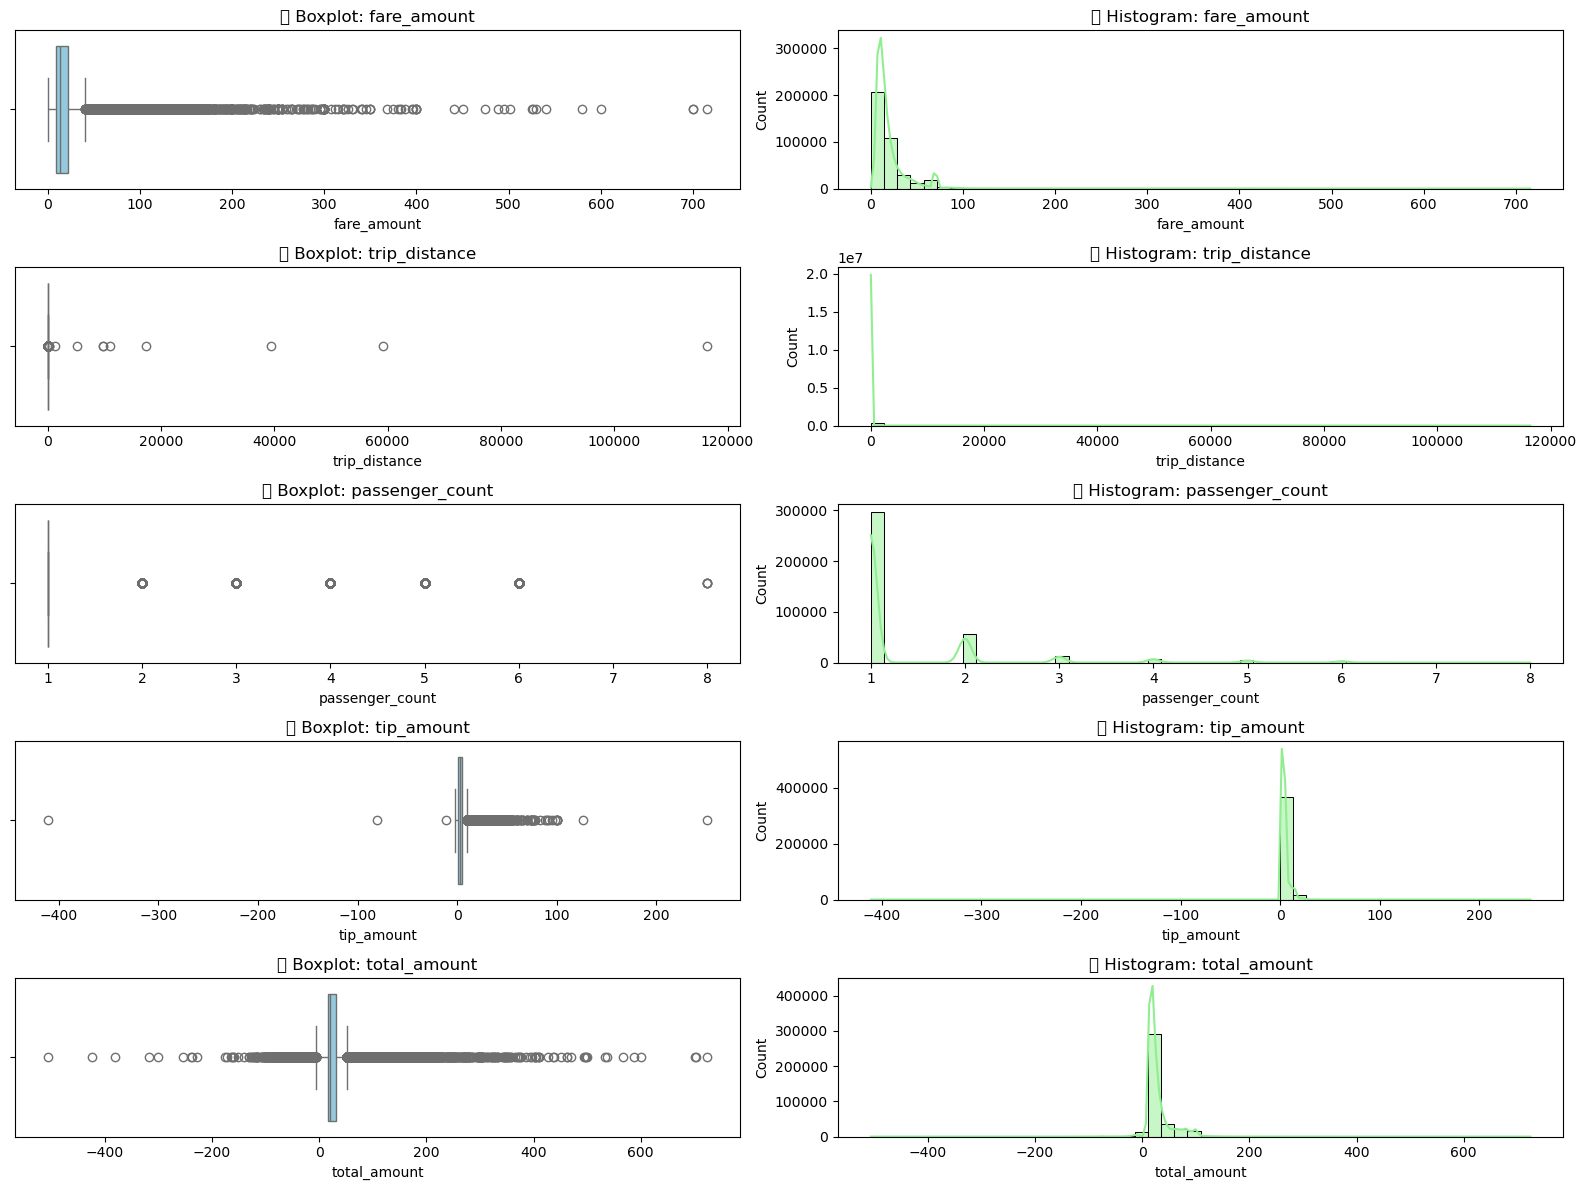

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to plot
cols = ['fare_amount', 'trip_distance', 'passenger_count', 'tip_amount', 'total_amount']

# Set up plots
plt.figure(figsize=(16, 12))
for i, col in enumerate(cols):
    plt.subplot(5, 2, 2*i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f"📦 Boxplot: {col}")

    plt.subplot(5, 2, 2*i + 2)
    sns.histplot(df[col], kde=True, bins=50, color='lightgreen')
    plt.title(f"Histogram: {col}")

plt.tight_layout()
plt.show()

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [102]:
# remove passenger_count > 6
# Count rows to be removed
count_removed = df[df['passenger_count'] > 6].shape[0]
print(f"Removing {count_removed} rows with passenger_count > 6")

# Filter the DataFrame
df = df[df['passenger_count'] <= 6]

print("Updated DataFrame now excludes passenger_count > 6")

Removing 4 rows with passenger_count > 6
Updated DataFrame now excludes passenger_count > 6


In [104]:
# Continue with outlier handling
#Remove entries where trip_distance ≈ 0 and fare_amount > 300
condition = (df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)
print(f"Removing {condition.sum()} rows with trip_distance ≈ 0 and fare > 300")
df = df[~condition]


Removing 12 rows with trip_distance ≈ 0 and fare > 300


In [106]:
#Remove entries where trip_distance = 0 and fare_amount = 0 but pickup & dropoff zones are different
if 'PULocationID' in df.columns and 'DOLocationID' in df.columns:
    condition = (
        (df['trip_distance'] == 0) &
        (df['fare_amount'] == 0) &
        (df['PULocationID'] != df['DOLocationID'])
    )
    print(f"Removing {condition.sum()} rows with zero fare & distance but different zones")
    df = df[~condition]

Removing 17 rows with zero fare & distance but different zones


In [108]:
#Remove entries where trip_distance > 250 miles
condition = df['trip_distance'] > 250
print(f"Removing {condition.sum()} rows with trip_distance > 250 miles")
df = df[~condition]

Removing 10 rows with trip_distance > 250 miles


In [110]:
# Remove entries where payment_type = 0 (invalid code) 
condition = df['payment_type'] == 0
print(f"Removing {condition.sum()} rows with payment_type = 0 (invalid)")
df = df[df['payment_type'] != 0]

Removing 12891 rows with payment_type = 0 (invalid)


/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_68100/1190328828.py:18: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


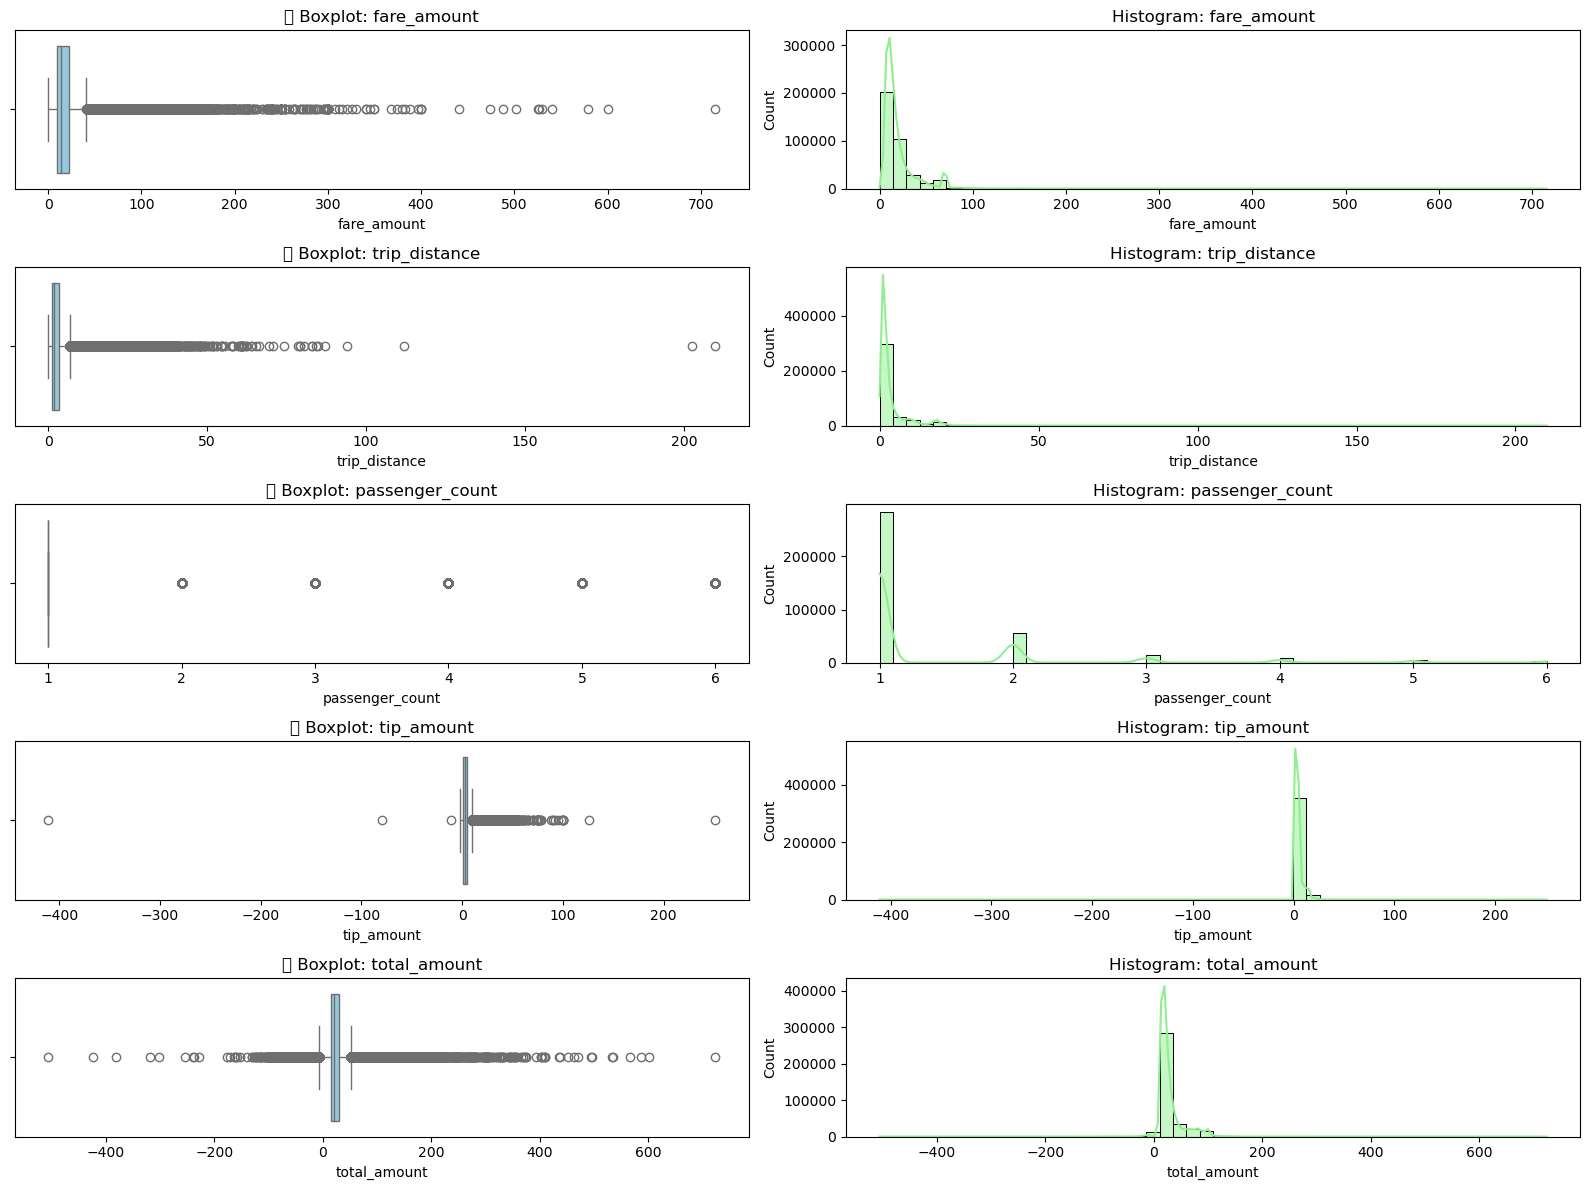

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to plot
cols = ['fare_amount', 'trip_distance', 'passenger_count', 'tip_amount', 'total_amount']

# Set up plots
plt.figure(figsize=(16, 12))
for i, col in enumerate(cols):
    plt.subplot(5, 2, 2*i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f"📦 Boxplot: {col}")

    plt.subplot(5, 2, 2*i + 2)
    sns.histplot(df[col], kde=True, bins=50, color='lightgreen')
    plt.title(f"Histogram: {col}")

plt.tight_layout()
plt.show()

In [116]:
# Do any columns need standardising?

# Select numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Drop categorical-like numeric columns that shouldn't be standardized
exclude_cols = ['passenger_count', 'RatecodeID', 'payment_type', 'PULocationID', 'DOLocationID']

# Columns to standardize
cols_to_standardize = [col for col in numeric_cols if col not in exclude_cols]
print("Columns suggested for standardization:\n", cols_to_standardize)

Columns suggested for standardization:
 ['index_col', 'VendorID', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [118]:
#lets take output before playing with standardization 
output_csv = "sampled_yellow_tripdata_2023_5.csv"
df.to_csv(output_csv, index=False)

# **3** Exploratory Data Analysis

In [120]:
df.columns.tolist()

['index_col',
 'VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

In [5]:
df = pd.read_csv(r"sampled_yellow_tripdata_2023_5.csv")

Numerical Variables
epresent quantities and can be measured, counted, or used in mathematical calculations.

passenger_count
trip_distance
pickup_hour
trip_duration


Monetary Columns (also Numerical):

These are continuous numeric values representing amounts.

fare_amount
extra
mta_tax
tip_amount
tolls_amount
improvement_surcharge
total_amount
congestion_surcharge
airport_fee

Categorical Variables
represent groups, labels, or codes with finite possible values.

VendorID
tpep_pickup_datetime (treated as datetime, not used as numerical)
tpep_dropoff_datetime (same as above)
RatecodeID
PULocationID
DOLocationID
payment_type

In [7]:
df.info

<bound method DataFrame.info of         index_col  VendorID tpep_pickup_datetime tpep_dropoff_datetime  \
0               0         2  2023-06-01 00:35:13   2023-06-01 01:12:51   
1               1         2  2023-06-01 00:43:37   2023-06-01 00:48:26   
2               2         2  2023-06-01 00:13:18   2023-06-01 00:19:43   
3               3         2  2023-06-01 00:17:04   2023-06-01 00:27:14   
4               4         2  2023-06-01 00:20:44   2023-06-01 00:39:33   
...           ...       ...                  ...                   ...   
370177     383111         2  2023-03-31 23:00:23   2023-03-31 23:08:40   
370178     383112         2  2023-03-31 23:39:07   2023-03-31 23:57:29   
370179     383113         2  2023-03-31 23:25:51   2023-03-31 23:34:38   
370180     383114         2  2023-03-31 23:01:06   2023-03-31 23:20:32   
370181     383115         1  2023-03-31 23:39:20   2023-04-01 00:04:53   

        passenger_count  trip_distance  RatecodeID store_and_fwd_flag  \
0     

##### Temporal Analysis

In [ ]:
**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

#3.1.2 Analyse the distribution of taxi pickups by hours, days of the week, and months.

/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/1856843299.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette="crest")


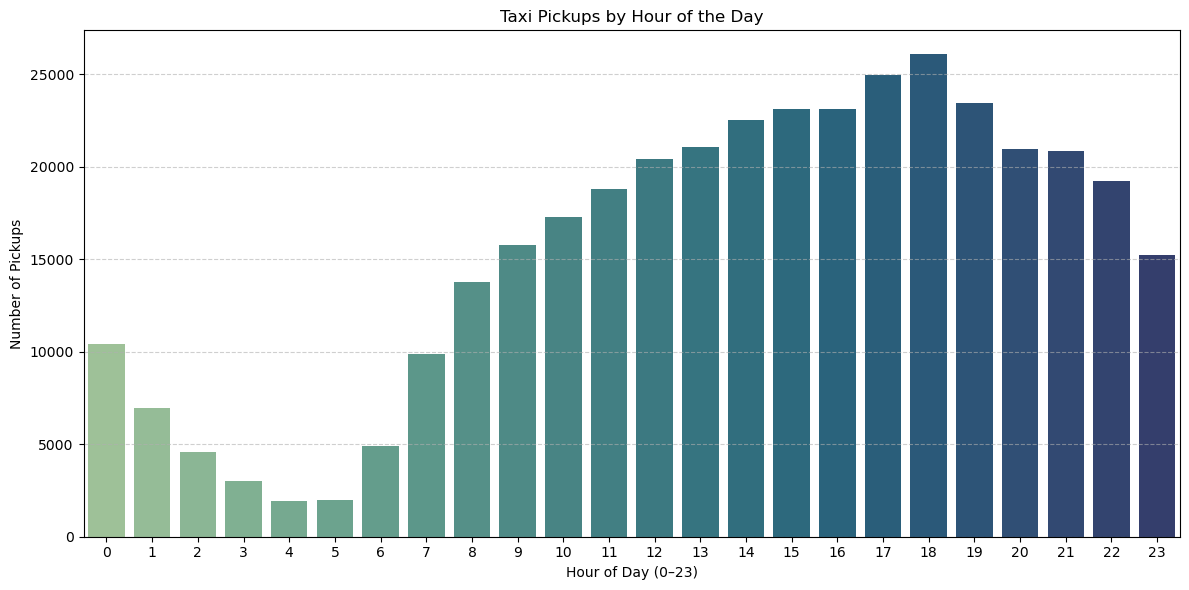

In [9]:
# Find and show the hourly trends in taxi pickups

# Create pickup_hour if not already present
if 'pickup_hour' not in df.columns:
    df['pickup_hour'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour

hourly_counts = df['pickup_hour'].value_counts().sort_index()

# Display the hourly pickup counts
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette="crest")
plt.title('Taxi Pickups by Hour of the Day')
plt.xlabel('Hour of Day (0–23)')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/886225328.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_counts.index, y=daily_counts.values, palette="mako")


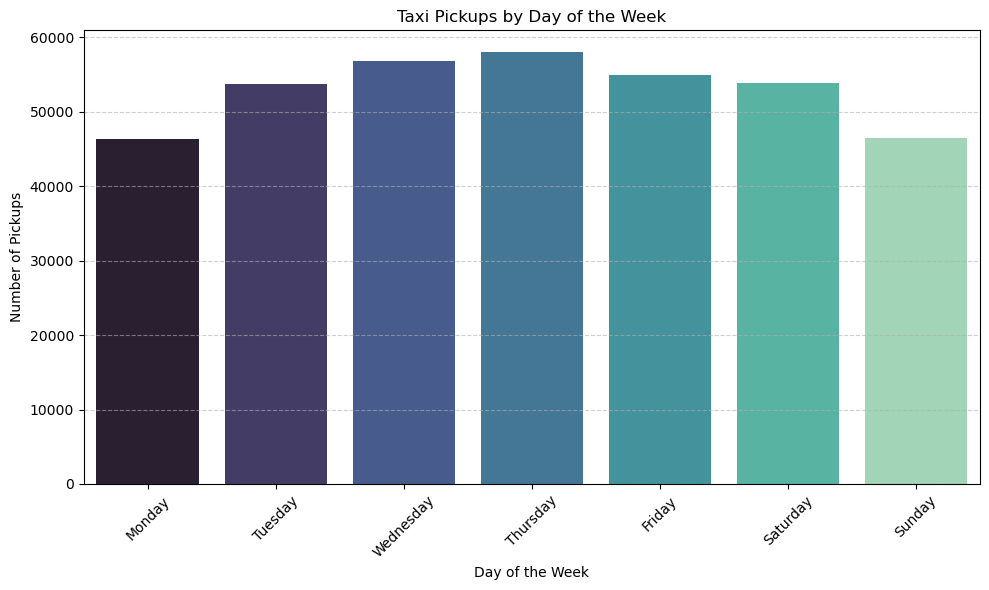

In [11]:
# Find and show the daily trends in taxi pickups (days of the week)

# Extract day of week from pickup datetime
df['pickup_dayofweek'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.dayofweek
# Map to weekday names (0 = Monday, ..., 6 = Sunday)
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
           4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['pickup_dayofweek'] = df['pickup_dayofweek'].map(day_map)

# Count pickups for each weekday
daily_counts = df['pickup_dayofweek'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=daily_counts.index, y=daily_counts.values, palette="mako")
plt.title("Taxi Pickups by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Pickups")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/17725675.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_counts.index, y=monthly_counts.values, palette="viridis")


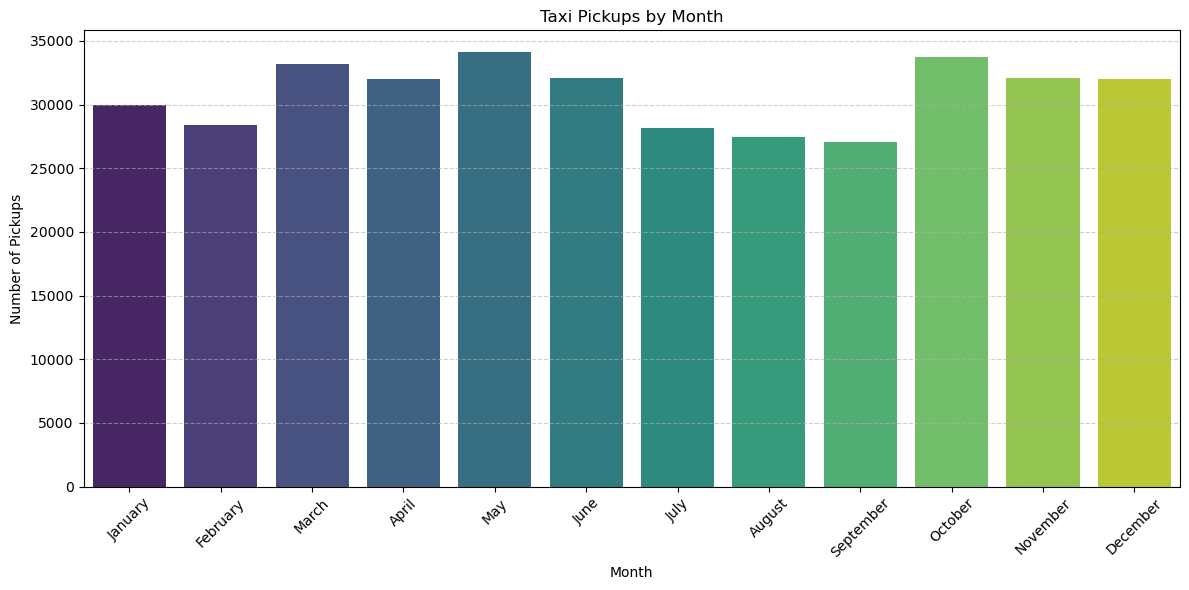

In [13]:
# Show the monthly trends in pickups

# Create pickup_month column if not present
df['pickup_month'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.month

# Optional: map month number to month name
import calendar
df['pickup_month'] = df['pickup_month'].map(lambda x: calendar.month_name[x])

# Count pickups per month and ensure order is correct
monthly_order = list(calendar.month_name)[1:]  # ['January', 'February', ..., 'December']
monthly_counts = df['pickup_month'].value_counts().reindex(monthly_order)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, palette="viridis")
plt.title("Taxi Pickups by Month")
plt.xlabel("Month")
plt.ylabel("Number of Pickups")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [16]:
# Analyse the above parameters
# List of financial columns to analyze
financial_cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

# Check for zero and negative values in each column
for col in financial_cols:
    total_rows = df.shape[0]
    zero_count = (df[col] == 0).sum()
    negative_count = (df[col] < 0).sum()
    
    print(f" {col} — Total: {total_rows}")
    print(f"Zero values: {zero_count} ({(zero_count / total_rows * 100):.2f}%)")
    print(f"Negative values: {negative_count} ({(negative_count / total_rows * 100):.2f}%)\n")


 fare_amount — Total: 370182
Zero values: 120 (0.03%)
Negative values: 0 (0.00%)

 tip_amount — Total: 370182
Zero values: 85711 (23.15%)
Negative values: 17 (0.00%)

 total_amount — Total: 370182
Zero values: 53 (0.01%)
Negative values: 3770 (1.02%)

 trip_distance — Total: 370182
Zero values: 5003 (1.35%)
Negative values: 0 (0.00%)



Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [18]:
# zero distance could be legitimate in cases like: Pickup & dropoff at the same location (e.g., waiting charges), Very short trips (under 0.1 mile) possibly rounded to 0,  Errors in data capture (e.g., GPS glitches).

#For now, we’ll retain those 0-distance trips but still filter out all zero values from the key financial columns (fare_amount, tip_amount, total_amount) and keep trip_distance as-is.

# Create a df with non zero entries for the selected parameters.
# Filter condition: keep only rows where financial values are non-zero
filtered_df = df[
    (df['fare_amount'] != 0) &
    (df['tip_amount'] != 0) &
    (df['total_amount'] != 0)
]

print(f"✅ Filtered data shape: {filtered_df.shape}")


✅ Filtered data shape: (284464, 23)


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [20]:
# Group data by month and analyse monthly revenue

# Ensure 'pickup_month' is extracted properly as a string (YYYY-MM format)
filtered_df['pickup_month'] = pd.to_datetime(filtered_df['tpep_pickup_datetime']).dt.to_period('M').astype(str)

# Group by month and calculate total revenue
monthly_revenue = (
    filtered_df.groupby('pickup_month')['total_amount']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={
        'sum': 'total_revenue',
        'mean': 'avg_revenue_per_trip',
        'count': 'trip_count'
    })
    .reset_index()
)

# Show the result
print("Monthly Revenue Summary:")
print(monthly_revenue)

Monthly Revenue Summary:
   pickup_month  total_revenue  avg_revenue_per_trip  trip_count
0       2023-01      653150.48             28.357161       23033
1       2023-02      621483.83             28.099825       22117
2       2023-03      742225.15             28.964884       25625
3       2023-04      728592.63             29.502455       24696
4       2023-05      789681.51             30.027055       26299
5       2023-06      745496.24             30.091880       24774
6       2023-07      626131.50             29.825728       20993
7       2023-08      608902.69             29.792675       20438
8       2023-09      644128.39             30.987078       20787
9       2023-10      809221.43             30.794635       26278
10      2023-11      748394.84             29.895136       25034
11      2023-12      729521.05             29.910662       24390


/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/2042871969.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['pickup_month'] = pd.to_datetime(filtered_df['tpep_pickup_datetime']).dt.to_period('M').astype(str)


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [22]:
# Calculate proportion of each quarter

# Create 'pickup_quarter' column
filtered_df['pickup_quarter'] = pd.to_datetime(filtered_df['tpep_pickup_datetime']).dt.to_period('Q').astype(str)

# Group by quarter and sum revenue
quarterly_revenue = (
    filtered_df.groupby('pickup_quarter')['total_amount']
    .sum()
    .reset_index()
    .rename(columns={'total_amount': 'total_revenue'})
)

# Calculate proportion of total revenue
total_annual_revenue = quarterly_revenue['total_revenue'].sum()
quarterly_revenue['revenue_proportion'] = (
    quarterly_revenue['total_revenue'] / total_annual_revenue
).round(4)  # rounded to 4 decimal places

# Display results
print("Revenue Proportion by Quarter:")
print(quarterly_revenue)

Revenue Proportion by Quarter:
  pickup_quarter  total_revenue  revenue_proportion
0         2023Q1     2016859.46              0.2388
1         2023Q2     2263770.38              0.2680
2         2023Q3     1879162.58              0.2225
3         2023Q4     2287137.32              0.2708


/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/69248102.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['pickup_quarter'] = pd.to_datetime(filtered_df['tpep_pickup_datetime']).dt.to_period('Q').astype(str)


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

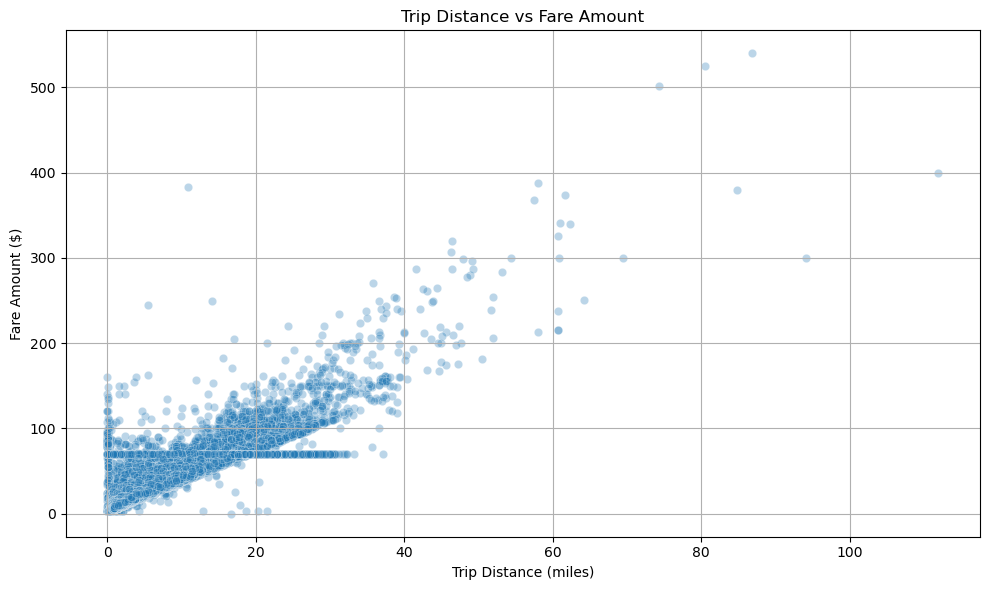

Correlation between trip_distance and fare_amount: 0.9498


In [24]:
# Show how trip fare is affected by distance

import matplotlib.pyplot as plt
import seaborn as sns

# Filter out zero-distance trips
distance_fare_df = filtered_df[filtered_df['trip_distance'] > 0]

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=distance_fare_df, x='trip_distance', y='fare_amount', alpha=0.3)
plt.title('Trip Distance vs Fare Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = distance_fare_df['trip_distance'].corr(distance_fare_df['fare_amount'])
print(f"Correlation between trip_distance and fare_amount: {correlation:.4f}")

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/40662181.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['trip_duration'] = (


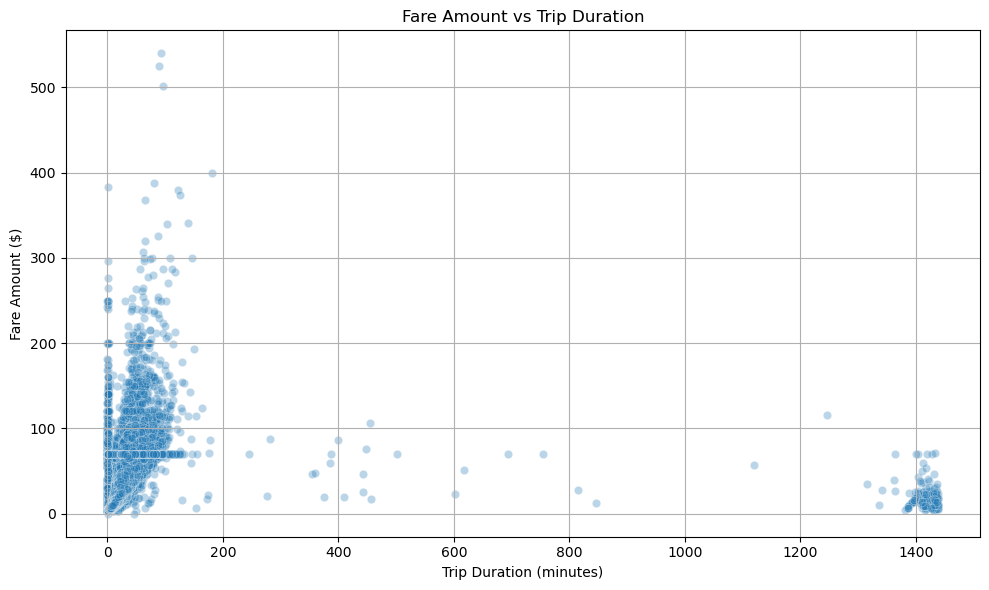

Correlation between trip_duration and fare_amount: 0.3064


In [26]:
# Show relationship between fare and trip duration
# Calculate trip_duration in minutes
filtered_df['trip_duration'] = (
    pd.to_datetime(filtered_df['tpep_dropoff_datetime']) - pd.to_datetime(filtered_df['tpep_pickup_datetime'])
).dt.total_seconds() / 60

# Filter for non-zero duration and fare
duration_fare_df = filtered_df[(filtered_df['trip_duration'] > 0) & (filtered_df['fare_amount'] > 0)]

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=duration_fare_df, x='trip_duration', y='fare_amount', alpha=0.3)
plt.title('Fare Amount vs Trip Duration')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Correlation
correlation = duration_fare_df['trip_duration'].corr(duration_fare_df['fare_amount'])
print(f"Correlation between trip_duration and fare_amount: {correlation:.4f}")


/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/1905988237.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fare_by_passenger, x='passenger_count', y='fare_amount', palette='Blues_d')


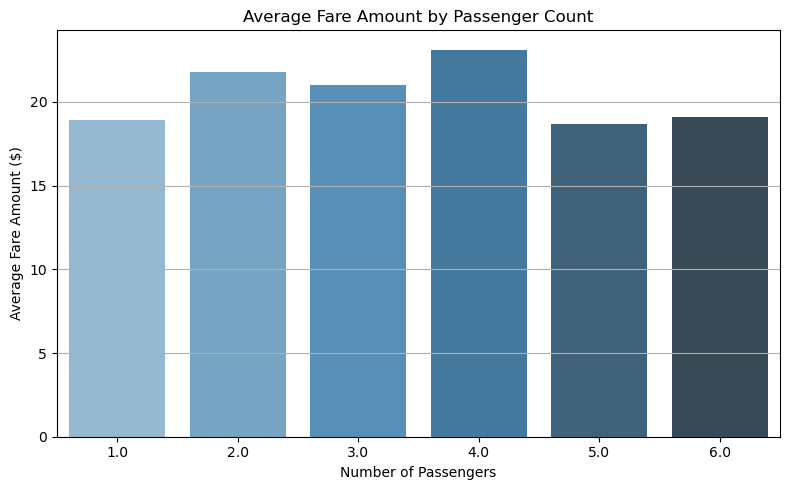

In [28]:
# Show relationship between fare and number of passengers

# Filter valid entries
fare_passenger_df = filtered_df[(filtered_df['fare_amount'] > 0) & (filtered_df['passenger_count'] > 0)]

# Group and calculate mean fare
fare_by_passenger = fare_passenger_df.groupby('passenger_count')['fare_amount'].mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=fare_by_passenger, x='passenger_count', y='fare_amount', palette='Blues_d')
plt.title('Average Fare Amount by Passenger Count')
plt.xlabel('Number of Passengers')
plt.ylabel('Average Fare Amount ($)')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

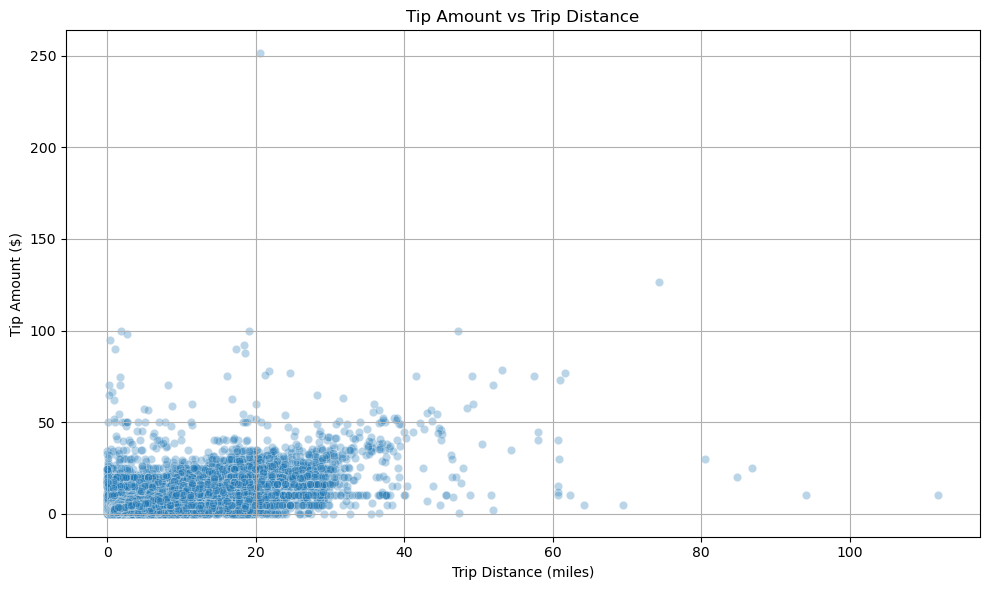

Correlation between trip_distance and tip_amount: 0.8029


In [30]:
# Show relationship between tip and trip distance

# Filter data where both tip and distance are greater than 0
tip_distance_df = filtered_df[(filtered_df['tip_amount'] > 0) & (filtered_df['trip_distance'] > 0)]

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tip_distance_df, x='trip_distance', y='tip_amount', alpha=0.3)
plt.title('Tip Amount vs Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Correlation
correlation = tip_distance_df['trip_distance'].corr(tip_distance_df['tip_amount'])
print(f"Correlation between trip_distance and tip_amount: {correlation:.4f}")

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/4080599871.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['payment_type_label'] = filtered_df['payment_type'].map(payment_mapping)
/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/4080599871.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='pastel')


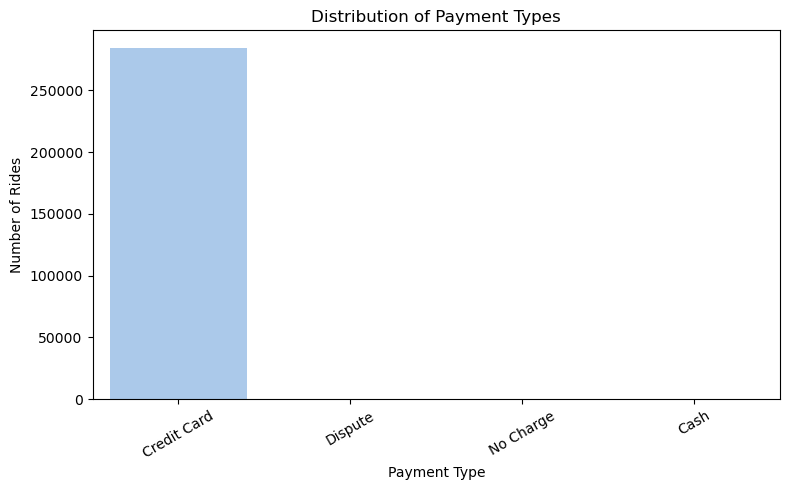

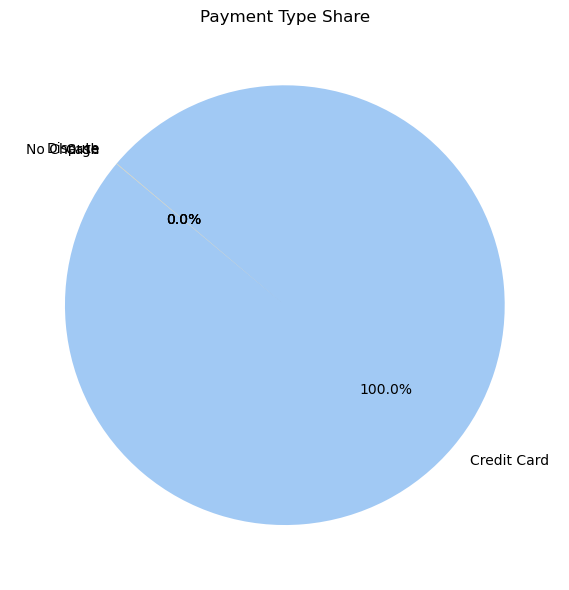

In [32]:
# Analyse the distribution of different payment types (payment_type).

payment_mapping = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided Trip'
}

filtered_df['payment_type_label'] = filtered_df['payment_type'].map(payment_mapping)

# Count the occurrences
payment_counts = filtered_df['payment_type_label'].value_counts()

# Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='pastel')
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Number of Rides')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Payment Type Share')
plt.tight_layout()
plt.show()


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [37]:
 !pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 3.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 3.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.9 MB/s eta 0:00:00a 0:00:01


**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [34]:
import geopandas as gpd
import fsspec

zones = gpd.read_file("NYCC/taxi_zones/taxi_zones.shp")

print(zones.head())

   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...  
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...  
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...  
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...  
4  Staten Island  POLYGON ((935843.31 144283.336, 936046.565 144...  


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

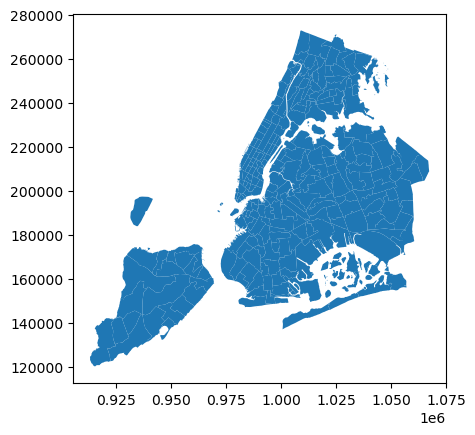

In [36]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [38]:
# Merge zones and trip records using locationID and PULocationID

zone_info = zones[['LocationID', 'zone', 'borough']].copy()

# Optional: Rename columns for clarity before merge
zone_info.rename(columns={'zone': 'PU_Zone', 'borough': 'PU_Borough'}, inplace=True)

# Step 2: Merge trip data with zone info on PULocationID
df = df.merge(zone_info, how='left', left_on='PULocationID', right_on='LocationID')

# Step 3: Drop the extra LocationID column added after merge
df.drop(columns=['LocationID'], inplace=True)

# Preview the result
print(df[['PULocationID', 'PU_Zone', 'PU_Borough']].head())

   PULocationID                    PU_Zone PU_Borough
0           142        Lincoln Square East  Manhattan
1           249               West Village  Manhattan
2           114    Greenwich Village South  Manhattan
3           170                Murray Hill  Manhattan
4           230  Times Sq/Theatre District  Manhattan


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [40]:
# Group data by location and calculate the number of trips

# Group by PULocationID and count the number of trips
pickup_counts = df.groupby('PULocationID').size().reset_index(name='trip_count')

# Sort to see most popular pickup locations
pickup_counts = pickup_counts.sort_values(by='trip_count', ascending=False)

# Preview the result
print(pickup_counts.head())

     PULocationID  trip_count
121           132       19857
219           237       17564
149           161       17156
218           236       15615
150           162       13120


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [42]:
# Merge pickup trip counts into zones GeoDataFrame
zones_trips = zones.merge(pickup_counts, left_on='LocationID', right_on='PULocationID', how='left')

# Fill NaN trip counts with 0 (locations with no trips)
zones_trips['trip_count'] = zones_trips['trip_count'].fillna(0).astype(int)

# Preview
print(zones_trips[['LocationID', 'zone', 'trip_count']].head())

   LocationID                     zone  trip_count
0           1           Newark Airport          52
1           2              Jamaica Bay           1
2           3  Allerton/Pelham Gardens           6
3           4            Alphabet City         364
4           5            Arden Heights           3


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

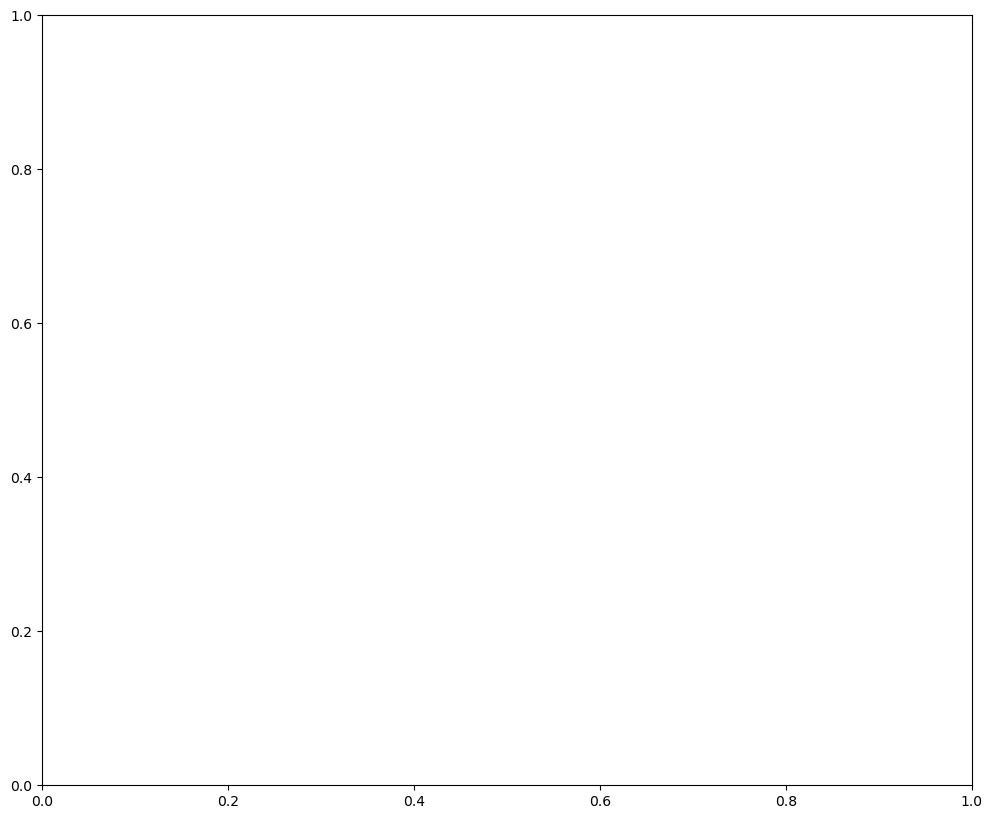

In [44]:
# Define figure and axis
import matplotlib.pyplot as plt

# Create the figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it



# 3.1.13** Plot a color-coded map showing zone-wise trips

In [46]:
trip_counts = trip_data.groupby('PULocationID').size().reset_index(name='num_trips')

NameError: name 'trip_data' is not defined

<Axes: >

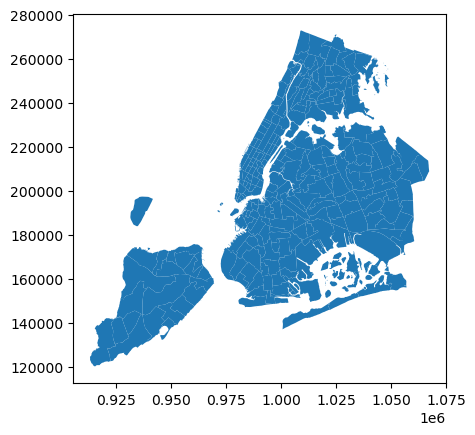

In [50]:
zones.plot() 

In [62]:
trip_counts = df.groupby('PULocationID').size().reset_index(name='num_trips')

In [64]:
zones = zones.merge(trip_counts, how='left', left_on='LocationID', right_on='PULocationID')

# Fill any NaNs in num_trips with 0 (zones with no pickups)
zones['num_trips'] = zones['num_trips'].fillna(0)

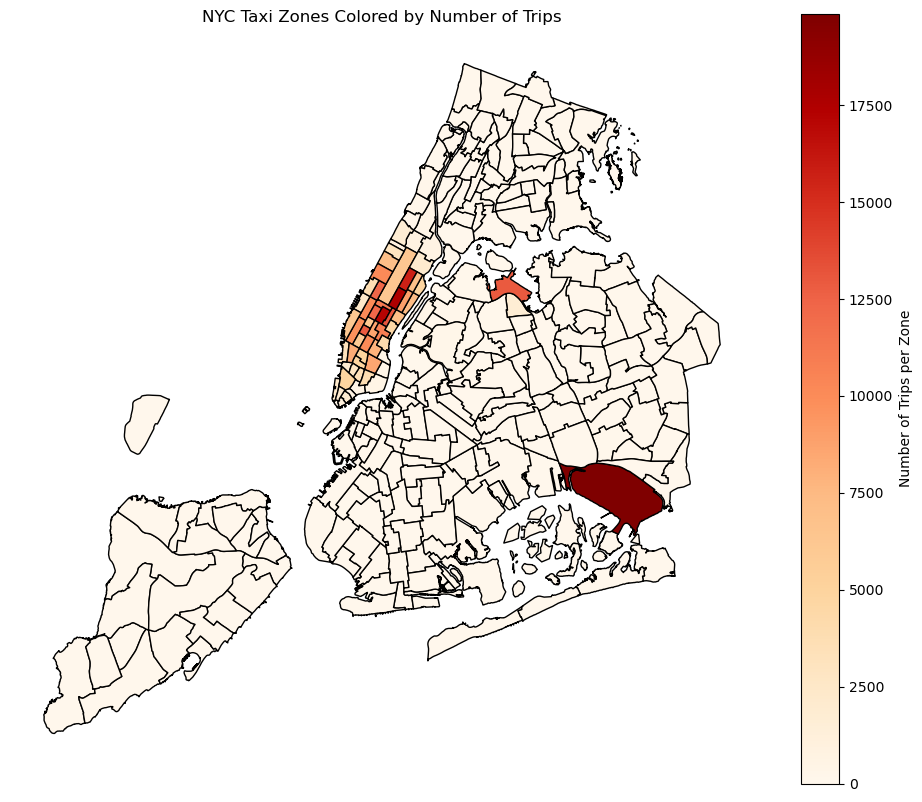

In [66]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones.plot(
    column='num_trips',
    ax=ax,
    legend=True,
    cmap='OrRd',
    edgecolor='black',
    legend_kwds={
        'label': "Number of Trips per Zone",
        'orientation': "vertical"
    }
)

plt.title("NYC Taxi Zones Colored by Number of Trips")
plt.axis('off')
plt.show()

In [68]:

# can you try displaying the zones DF sorted by the number of trips?
# Sort zones GeoDataFrame by number of trips in descending order
sorted_zones = zones.sort_values(by='num_trips', ascending=False)

# Display the top 10 zones with the most trips
print(sorted_zones[['LocationID', 'zone', 'borough', 'num_trips']].head(10))


     LocationID                          zone    borough  num_trips
131         132                   JFK Airport     Queens    19857.0
236         237         Upper East Side South  Manhattan    17564.0
160         161                Midtown Center  Manhattan    17156.0
235         236         Upper East Side North  Manhattan    15615.0
161         162                  Midtown East  Manhattan    13120.0
137         138             LaGuardia Airport     Queens    12943.0
185         186  Penn Station/Madison Sq West  Manhattan    12907.0
141         142           Lincoln Square East  Manhattan    12332.0
229         230     Times Sq/Theatre District  Manhattan    12183.0
162         163                 Midtown North  Manhattan    10970.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

How does identifying high-traffic, high-demand routes help us?

In [70]:
# Ensure datetime columns are in datetime format
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Create required columns
df['trip_duration_hrs'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 3600
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

# Filter out zero/negative duration or distance
df_valid = df[(df['trip_duration_hrs'] > 0) & (df['trip_distance'] > 0)]

# Create route key and calculate avg speed
df_valid['route'] = df_valid['PULocationID'].astype(str) + " → " + df_valid['DOLocationID'].astype(str)
route_speed = df_valid.groupby(['route', 'pickup_hour']).agg(
    avg_duration=('trip_duration_hrs', 'mean'),
    avg_distance=('trip_distance', 'mean')
).reset_index()
route_speed['avg_speed'] = route_speed['avg_distance'] / route_speed['avg_duration']

# Now get the slowest route per hour
slowest_routes_by_hour = route_speed.sort_values(['pickup_hour', 'avg_speed']).groupby('pickup_hour').head(1)

# Display result
print(slowest_routes_by_hour)

           route  pickup_hour  avg_duration  avg_distance  avg_speed
52057    25 → 25            0     61.843056     12.210000   0.197435
41854  233 → 229            1      7.962778      0.803333   0.100886
28236  163 → 237            2     23.822222      1.460000   0.061287
23337  158 → 100            3     22.915833      2.220000   0.096876
38911  230 → 229            4     11.795694      0.805000   0.068245
32551  182 → 137            5      0.795000      0.500000   0.628931
18775   142 → 48            6      3.475833      0.834286   0.240025
58967   48 → 179            7     23.719444      5.960000   0.251271
68909   90 → 164            8      4.858833      0.894000   0.183995
3683   113 → 244            9      4.956389      0.420000   0.084739
32447    18 → 74           10      0.858333      0.100000   0.116505
33      10 → 145           11      1.671111      0.100000   0.059840
65249   79 → 100           12     23.972778      2.410000   0.100531
5718   125 → 113           13     

/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/1880228711.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid['route'] = df_valid['PULocationID'].astype(str) + " → " + df_valid['DOLocationID'].astype(str)


**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/555288131.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trips_per_hour.index, y=trips_per_hour.values, palette='viridis')


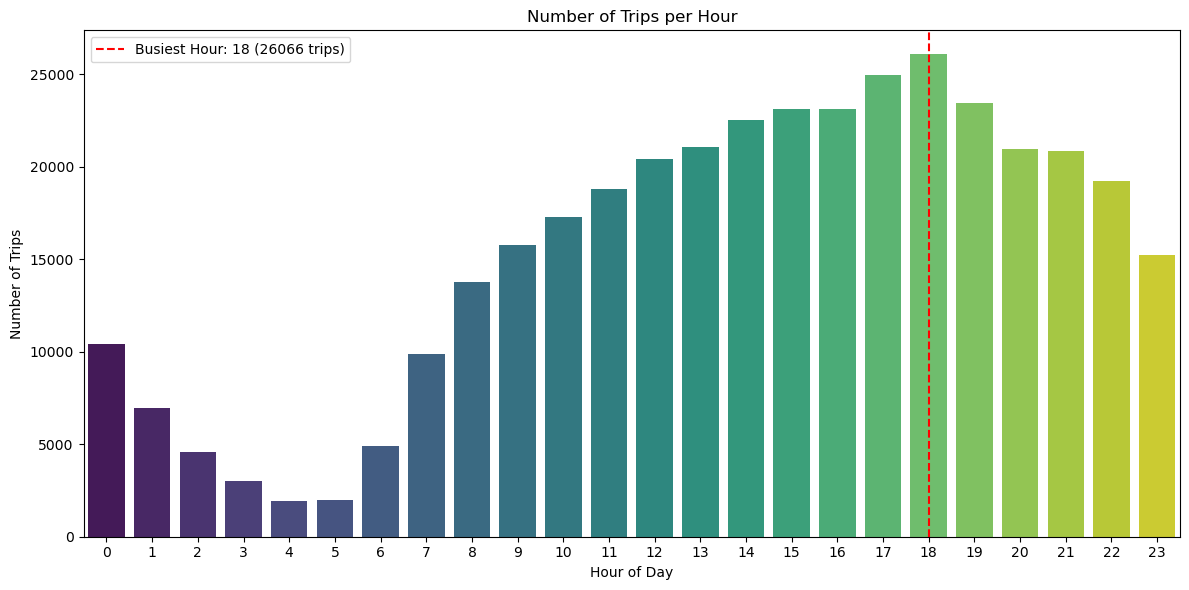

In [72]:
# Visualise the number of trips per hour and find the busiest hour

import matplotlib.pyplot as plt
import seaborn as sns

# Extract pickup hour if not already present
df['pickup_hour'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour

# Count number of trips per hour
trips_per_hour = df['pickup_hour'].value_counts().sort_index()

# Find busiest hour
busiest_hour = trips_per_hour.idxmax()
num_trips = trips_per_hour.max()

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=trips_per_hour.index, y=trips_per_hour.values, palette='viridis')
plt.title('Number of Trips per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.axvline(busiest_hour, color='red', linestyle='--', label=f'Busiest Hour: {busiest_hour} ({num_trips} trips)')
plt.legend()
plt.tight_layout()
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/1267833518.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=trips_per_hour_scaled.index, y=trips_per_hour_scaled.values, palette='mako')


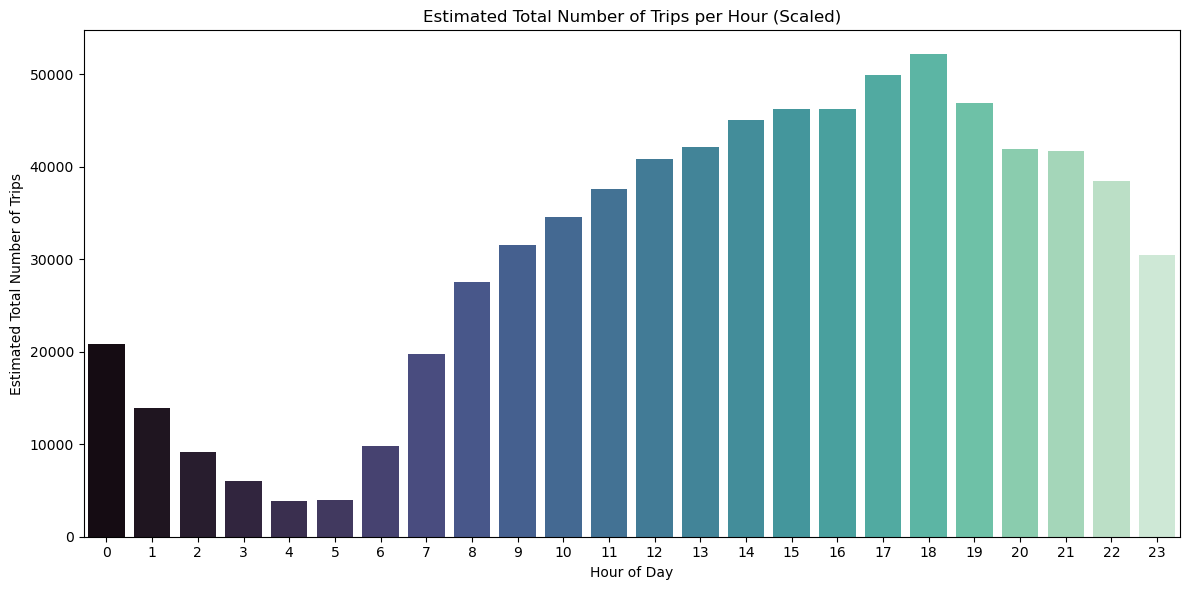

In [74]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
#sample_fraction =
sample_fraction = 0.5

# Scale up trip counts
trips_per_hour_scaled = trips_per_hour / sample_fraction

# Plot scaled values
plt.figure(figsize=(12,6))
sns.barplot(x=trips_per_hour_scaled.index, y=trips_per_hour_scaled.values, palette='mako')
plt.title('Estimated Total Number of Trips per Hour (Scaled)')
plt.xlabel('Hour of Day')
plt.ylabel('Estimated Total Number of Trips')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

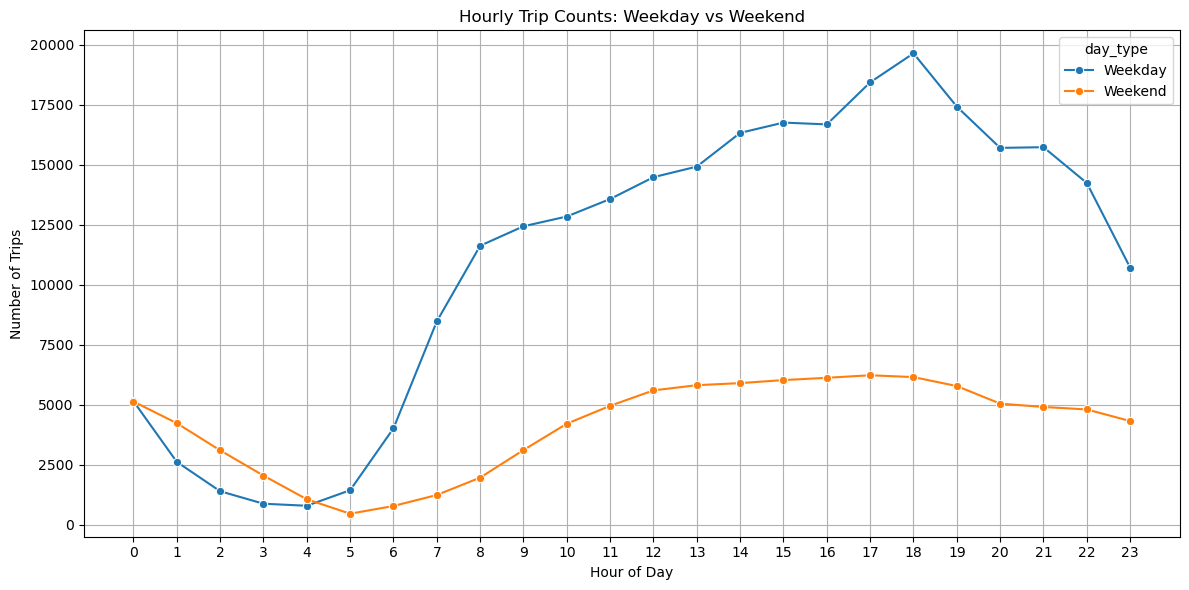

In [107]:
# Compare traffic trends for the week days and weekends

df['pickup_hour'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour
df['pickup_day'] = pd.to_datetime(df['tpep_pickup_datetime']).dt.dayofweek  # Monday=0, Sunday=6
df['day_type'] = df['pickup_day'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
hourly_counts = df.groupby(['pickup_hour', 'day_type']).size().reset_index(name='num_trips')

plt.figure(figsize=(12,6))
sns.lineplot(data=hourly_counts, x='pickup_hour', y='num_trips', hue='day_type', marker='o')
plt.title("Hourly Trip Counts: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [76]:
# Find top 10 pickup and dropoff zones

# Top 10 pickup zones
top_10_pu = df['PULocationID'].value_counts().head(10).index.tolist()

# Top 10 dropoff zones
top_10_do = df['DOLocationID'].value_counts().head(10).index.tolist()

print("Top 10 Pickup Zones:", top_10_pu)
print("Top 10 Dropoff Zones:", top_10_do)


Top 10 Pickup Zones: [132, 237, 161, 236, 162, 138, 186, 142, 230, 163]
Top 10 Dropoff Zones: [236, 237, 161, 230, 170, 142, 239, 162, 141, 163]


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [78]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

# Count pickups and dropoffs
pickup_counts = df['PULocationID'].value_counts().rename('pickups')
dropoff_counts = df['DOLocationID'].value_counts().rename('dropoffs')

# Combine counts into one DataFrame
zone_ratios = pd.concat([pickup_counts, dropoff_counts], axis=1).fillna(0)

# Avoid division by zero
zone_ratios = zone_ratios[zone_ratios['dropoffs'] != 0]

# Compute pickup/dropoff ratio
zone_ratios['pickup_drop_ratio'] = zone_ratios['pickups'] / zone_ratios['dropoffs']

# Top 10 zones with highest ratio
top_10_ratio = zone_ratios.sort_values('pickup_drop_ratio', ascending=False).head(10)

# Bottom 10 zones with lowest ratio
bottom_10_ratio = zone_ratios.sort_values('pickup_drop_ratio').head(10)

# Display results
print("Top 10 Pickup/Dropoff Ratios:")
print(top_10_ratio)

print("\nBottom 10 Pickup/Dropoff Ratios:")
print(bottom_10_ratio)

Top 10 Pickup/Dropoff Ratios:
     pickups  dropoffs  pickup_drop_ratio
70    1689.0       256           6.597656
132  19857.0      4415           4.497622
138  12943.0      4474           2.892937
186  12907.0      8124           1.588749
43    6273.0      4522           1.387218
114   4856.0      3579           1.356804
249   8255.0      6136           1.345339
162  13120.0     10299           1.273910
142  12332.0     10458           1.179193
100   6120.0      5215           1.173538

Bottom 10 Pickup/Dropoff Ratios:
     pickups  dropoffs  pickup_drop_ratio
187      0.0         1                0.0
204      0.0         2                0.0
111      0.0         3                0.0
115      0.0         3                0.0
245      0.0         5                0.0
172      0.0         5                0.0
251      0.0         5                0.0
57       0.0         5                0.0
221      0.0         6                0.0
156      0.0         9                0.0


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [113]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Convert pickup and dropoff datetime columns if not already datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Extract pickup hour
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

# Filter trips in night hours (11 PM to 5 AM)
night_df = df[(df['pickup_hour'] >= 23) | (df['pickup_hour'] <= 5)]

# Count night pickups by zone
night_pickups = night_df['PULocationID'].value_counts().head(10)

# Count night dropoffs by zone
night_dropoffs = night_df['DOLocationID'].value_counts().head(10)

# Display results
print("Top 10 Pickup Zones (11 PM - 5 AM):")
print(night_pickups)

print("\nTop 10 Dropoff Zones (11 PM - 5 AM):")
print(night_dropoffs)

Top 10 Pickup Zones (11 PM - 5 AM):
PULocationID
79     3099
132    2878
249    2494
48     2105
148    1934
114    1753
230    1634
186    1414
164    1252
138    1231
Name: count, dtype: int64

Top 10 Dropoff Zones (11 PM - 5 AM):
DOLocationID
79     1646
48     1429
170    1237
68     1168
107    1160
141    1053
263    1006
230     979
249     953
229     930
Name: count, dtype: int64


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [80]:
# Filter for night hours (11 PM to 5 AM)

# Ensure datetime format
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Extract hour
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

# Create night and day filters
night_mask = (df['pickup_hour'] >= 23) | (df['pickup_hour'] <= 5)
day_mask = (df['pickup_hour'] >= 6) & (df['pickup_hour'] <= 22)

# Total revenue (assuming we're using fare_amount + tip_amount)
df['total_revenue'] = df['fare_amount'] + df['tip_amount']

# Calculate revenue shares
night_revenue = df.loc[night_mask, 'total_revenue'].sum()
day_revenue = df.loc[day_mask, 'total_revenue'].sum()
total_revenue = df['total_revenue'].sum()

night_share = night_revenue / total_revenue * 100
day_share = day_revenue / total_revenue * 100

# Display result
print(f"Nighttime Revenue Share (11 PM to 5 AM): {night_share:.2f}%")
print(f"Daytime Revenue Share (6 AM to 10 PM): {day_share:.2f}%")

Nighttime Revenue Share (11 PM to 5 AM): 12.18%
Daytime Revenue Share (6 AM to 10 PM): 87.82%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [82]:
# Analyse the fare per mile per passenger for different passenger counts

# Filter out invalid entries
valid_df = df[(df['trip_distance'] > 0) & 
              (df['fare_amount'] > 0) & 
              (df['passenger_count'] > 0)]

# Calculate fare per mile per passenger
valid_df['fare_per_mile_per_passenger'] = valid_df['fare_amount'] / (valid_df['trip_distance'] * valid_df['passenger_count'])

# Group by passenger count and get average
fare_analysis = valid_df.groupby('passenger_count')['fare_per_mile_per_passenger'].mean().reset_index()

# Sort and display
fare_analysis = fare_analysis.sort_values(by='fare_per_mile_per_passenger')
print(fare_analysis)


   passenger_count  fare_per_mile_per_passenger
5              6.0                     1.527669
4              5.0                     1.719255
2              3.0                     4.635596
3              4.0                     5.864931
1              2.0                     7.503377
0              1.0                    11.724318


/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/2152054068.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['fare_per_mile_per_passenger'] = valid_df['fare_amount'] / (valid_df['trip_distance'] * valid_df['passenger_count'])


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [84]:
# Compare the average fare per mile for different days and for different times of the day

# Filter valid trips
valid_df = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)]

# Create time-based columns
valid_df['pickup_hour'] = valid_df['tpep_pickup_datetime'].dt.hour
valid_df['pickup_dayofweek'] = valid_df['tpep_pickup_datetime'].dt.day_name()

# Calculate fare per mile
valid_df['fare_per_mile'] = valid_df['fare_amount'] / valid_df['trip_distance']

# Group by hour of the day
fare_by_hour = valid_df.groupby('pickup_hour')['fare_per_mile'].mean().reset_index()

# Group by day of the week
fare_by_day = valid_df.groupby('pickup_dayofweek')['fare_per_mile'].mean().reset_index()

# Sort days in proper order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fare_by_day['pickup_dayofweek'] = pd.Categorical(fare_by_day['pickup_dayofweek'], categories=day_order, ordered=True)
fare_by_day = fare_by_day.sort_values('pickup_dayofweek')

# Display
print("Average Fare per Mile by Hour:\n", fare_by_hour)
print("\nAverage Fare per Mile by Day:\n", fare_by_day)


Average Fare per Mile by Hour:
     pickup_hour  fare_per_mile
0             0      13.493131
1             1      13.481011
2             2      13.089807
3             3       9.885608
4             4      17.849949
5             5      11.922881
6             6      12.977705
7             7      11.619992
8             8      10.486667
9             9      11.254242
10           10      10.421483
11           11      13.212478
12           12      12.606874
13           13      14.564648
14           14      13.806819
15           15      14.787253
16           16      14.823203
17           17      14.551925
18           18      10.550666
19           19      11.547449
20           20       9.458711
21           21      12.826797
22           22       9.743347
23           23      12.723287

Average Fare per Mile by Day:
   pickup_dayofweek  fare_per_mile
1           Monday      11.827658
5          Tuesday      11.658567
6        Wednesday      11.294869
4         Thursday      1

/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/1928057860.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['pickup_hour'] = valid_df['tpep_pickup_datetime'].dt.hour
/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/1928057860.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['pickup_dayofweek'] = valid_df['tpep_pickup_datetime'].dt.day_name()
/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/1928057860.py:11: SettingWithCopyWarning: 
A valu

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [86]:
# Compare fare per mile for different vendors

# Filter valid trips
valid_df = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)]

# Extract pickup hour
valid_df['pickup_hour'] = valid_df['tpep_pickup_datetime'].dt.hour

# Compute fare per mile
valid_df['fare_per_mile'] = valid_df['fare_amount'] / valid_df['trip_distance']

# Group by Vendor and Hour
fare_by_vendor_hour = valid_df.groupby(['VendorID', 'pickup_hour'])['fare_per_mile'].mean().reset_index()

# Display
fare_by_vendor_hour.head(10)  # Show sample

/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/2880335260.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['pickup_hour'] = valid_df['tpep_pickup_datetime'].dt.hour
/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/2880335260.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['fare_per_mile'] = valid_df['fare_amount'] / valid_df['trip_distance']


,VendorID,pickup_hour,fare_per_mile
0,1,0,7.089932
1,1,1,6.645040
2,1,2,6.846856
3,1,3,6.476474
4,1,4,6.386146
5,1,5,7.581645
6,1,6,6.401602
7,1,7,7.249930
8,1,8,8.151522
9,1,9,9.309050


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [88]:
# Defining distance tiers

# Use only valid data
valid_df = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)].copy()

# Compute fare per mile
valid_df['fare_per_mile'] = valid_df['fare_amount'] / valid_df['trip_distance']

# Create distance tier
def distance_tier(d):
    if d <= 2:
        return '0-2 miles'
    elif d <= 5:
        return '2-5 miles'
    else:
        return '5+ miles'

valid_df['distance_tier'] = valid_df['trip_distance'].apply(distance_tier)

# Group by Vendor and Distance Tier
tiered_fare = valid_df.groupby(['VendorID', 'distance_tier'])['fare_per_mile'].mean().reset_index()

# Display results
tiered_fare.sort_values(['distance_tier', 'VendorID'])

,VendorID,distance_tier,fare_per_mile
0,1,0-2 miles,9.976762
3,2,0-2 miles,20.777095
1,1,2-5 miles,6.400106
4,2,2-5 miles,6.553744
2,1,5+ miles,4.432051
5,2,5+ miles,4.504535


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [90]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

# Filter for valid fare and tip amounts
tip_df = df[(df['fare_amount'] > 0) & (df['tip_amount'] >= 0)].copy()

# Calculate tip percentage
tip_df['tip_pct'] = (tip_df['tip_amount'] / tip_df['fare_amount']) * 100

# Add relevant columns
tip_df['pickup_hour'] = tip_df['tpep_pickup_datetime'].dt.hour
tip_df = tip_df[(tip_df['trip_distance'] > 0) & (tip_df['passenger_count'] > 0)]

# Group by trip distance ranges
tip_df['distance_range'] = pd.cut(tip_df['trip_distance'],
                                  bins=[0, 2, 5, 10, 20, float('inf')],
                                  labels=['0-2 mi', '2-5 mi', '5-10 mi', '10-20 mi', '20+ mi'])

# Group and aggregate
tip_summary = tip_df.groupby(['distance_range', 'passenger_count', 'pickup_hour'])['tip_pct'].mean().reset_index()

# Display top rows
tip_summary.head()

/var/folders/4m/rg8sls6x17s26_c4_71vgxv40000gn/T/ipykernel_9424/3493187192.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tip_summary = tip_df.groupby(['distance_range', 'passenger_count', 'pickup_hour'])['tip_pct'].mean().reset_index()


,distance_range,passenger_count,pickup_hour,tip_pct
0,0-2 mi,1.0,0,23.443525
1,0-2 mi,1.0,1,23.092744
2,0-2 mi,1.0,2,24.436530
3,0-2 mi,1.0,3,22.311532
4,0-2 mi,1.0,4,21.935543


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

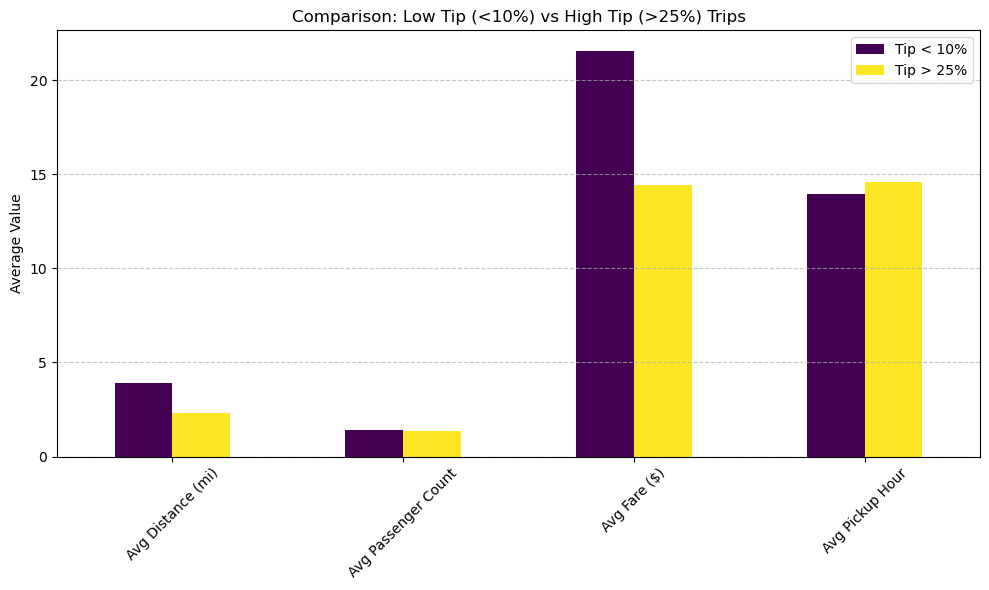

In [92]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

# Define thresholds
low_tip = tip_df[tip_df['tip_pct'] < 10]
high_tip = tip_df[tip_df['tip_pct'] > 25]

# Compare average values
comparison = pd.DataFrame({
    'Avg Distance (mi)': [low_tip['trip_distance'].mean(), high_tip['trip_distance'].mean()],
    'Avg Passenger Count': [low_tip['passenger_count'].mean(), high_tip['passenger_count'].mean()],
    'Avg Fare ($)': [low_tip['fare_amount'].mean(), high_tip['fare_amount'].mean()],
    'Avg Pickup Hour': [low_tip['pickup_hour'].mean(), high_tip['pickup_hour'].mean()]
}, index=['Tip < 10%', 'Tip > 25%'])


import matplotlib.pyplot as plt

# Plot setup
comparison.T.plot(kind='bar', figsize=(10,6), colormap='viridis')
plt.title('Comparison: Low Tip (<10%) vs High Tip (>25%) Trips')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

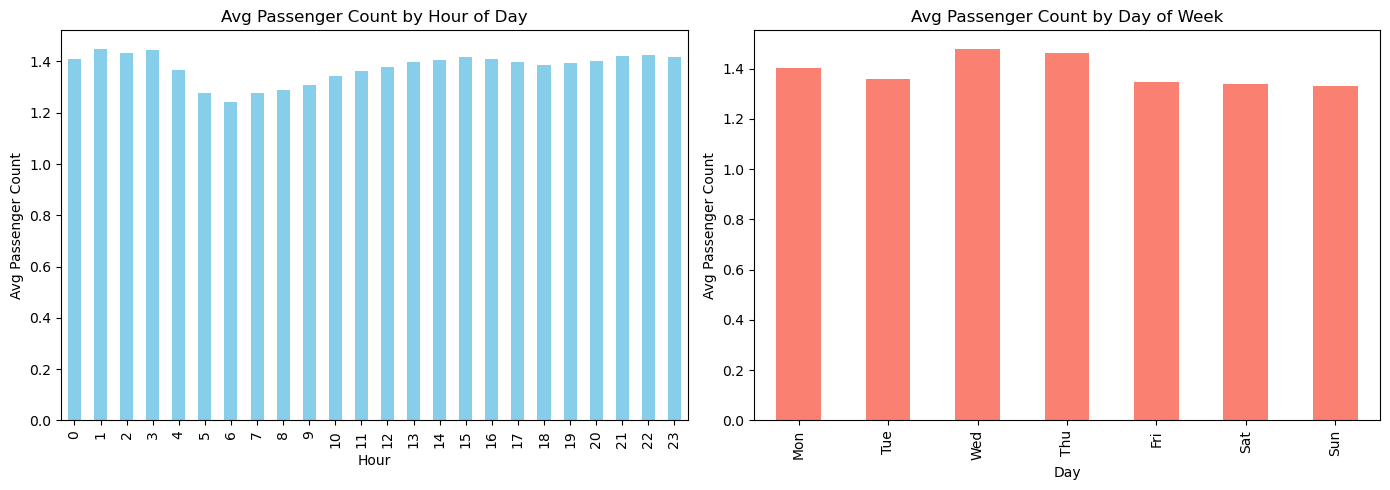

In [94]:
# See how passenger count varies across hours and days

# Average passenger count by hour of the day
avg_passenger_by_hour = df.groupby('pickup_hour')['passenger_count'].mean()

# Average passenger count by day of the week
avg_passenger_by_day = df.groupby('pickup_dayofweek')['passenger_count'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Hourly variation
avg_passenger_by_hour.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Avg Passenger Count by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg Passenger Count')

# Daily variation
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
avg_passenger_by_day.index = days
avg_passenger_by_day.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Avg Passenger Count by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Avg Passenger Count')

plt.tight_layout()
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [104]:
# How does passenger count vary across zones

# Group by PULocationID and calculate average passenger count
avg_passenger_by_zone = df.groupby('PULocationID')['passenger_count'].mean().reset_index()

# Merge with zone names for better readability
avg_passenger_by_zone = avg_passenger_by_zone.merge(zones, left_on='PULocationID', right_on='LocationID')


#print(avg_passenger_by_zone_sorted.columns.tolist())


avg_passenger_by_zone_sorted.head(10)

,PULocationID_x,passenger_count,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID_y,num_trips
53,54,2.500000,54,0.076219,0.000132,Columbia Street,54,Brooklyn,"MULTIPOLYGON (((983766.472 191538.898, 983138....",54.0,2.0
5,6,2.250000,6,0.150491,0.000606,Arrochar/Fort Wadsworth,6,Staten Island,"POLYGON ((966568.747 158679.855, 966615.256 15...",6.0,4.0
11,12,1.786585,12,0.036661,0.000042,Battery Park,12,Manhattan,"POLYGON ((979908.772 196066.565, 979980.852 19...",12.0,164.0
201,217,1.750000,217,0.055391,0.000115,South Williamsburg,217,Brooklyn,"POLYGON ((996576.041 197074.987, 996998.846 19...",217.0,8.0
0,1,1.711538,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,52.0
91,93,1.675325,93,0.170998,0.000594,Flushing Meadows-Corona Park,93,Queens,"POLYGON ((1023873.126 217682.009, 1023953.196 ...",93.0,77.0
15,16,1.666667,16,0.141292,0.000872,Bayside,16,Queens,"POLYGON ((1048344.039 223210.621, 1048409.575 ...",16.0,3.0
203,219,1.621622,219,0.155127,0.000428,Springfield Gardens South,219,Queens,"POLYGON ((1050324.836 182327.776, 1050609.77 1...",219.0,37.0
9,10,1.618705,10,0.099839,0.000436,Baisley Park,10,Queens,"POLYGON ((1044355.072 190734.321, 1044612.122 ...",10.0,139.0
124,134,1.607143,134,0.069588,0.000202,Kew Gardens,134,Queens,"POLYGON ((1033351.692 198700.728, 1033451.285 ...",134.0,28.0


In [108]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

# Aggregate passenger count and trip count by pickup location ID
zone_trip_stats = df.groupby('PULocationID').agg(
    total_passenger_count=('passenger_count', 'sum'),
    total_trip_count=('passenger_count', 'count')
).reset_index()

# Merge with zone shapefile data
zones_with_trips = zones.merge(zone_trip_stats, left_on='LocationID', right_on='PULocationID')

In [110]:
zones_with_trips['avg_passenger_per_trip'] = zones_with_trips['total_passenger_count'] / zones_with_trips['total_trip_count']

In [116]:
zones_with_trips[['zone', 'borough', 'avg_passenger_per_trip']]\
    .sort_values(by='avg_passenger_per_trip', ascending=False)\
    .head(10)

,zone,borough,avg_passenger_per_trip
53,Columbia Street,Brooklyn,2.500000
5,Arrochar/Fort Wadsworth,Staten Island,2.250000
11,Battery Park,Manhattan,1.786585
201,South Williamsburg,Brooklyn,1.750000
0,Newark Airport,EWR,1.711538
91,Flushing Meadows-Corona Park,Queens,1.675325
15,Bayside,Queens,1.666667
203,Springfield Gardens South,Queens,1.621622
9,Baisley Park,Queens,1.618705
124,Kew Gardens,Queens,1.607143


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [118]:
# How often is each surcharge applied?

# Count non-zero occurrences for each surcharge type
surcharge_counts = {
    'MTA_tax_applied': (df['mta_tax'] > 0).sum(),
    'Improvement_surcharge_applied': (df['improvement_surcharge'] > 0).sum(),
    'Congestion_surcharge_applied': (df['congestion_surcharge'] > 0).sum()
}

# Also get percentage out of total
total_trips = len(df)
surcharge_percentages = {k: f"{v / total_trips * 100:.2f}%" for k, v in surcharge_counts.items()}

# Combine and display
for surcharge, count in surcharge_counts.items():
    print(f"{surcharge}: {count} trips ({surcharge_percentages[surcharge]})")

MTA_tax_applied: 362908 trips (98.03%)
Improvement_surcharge_applied: 366287 trips (98.94%)
Congestion_surcharge_applied: 338180 trips (91.35%)


In [122]:
print(df.columns)

Index(['index_col', 'VendorID', 'tpep_pickup_datetime',
       'tpep_dropoff_datetime', 'passenger_count', 'trip_distance',
       'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'Airport_fee', 'pickup_hour',
       'pickup_dayofweek', 'pickup_month', 'PU_Zone', 'PU_Borough',
       'trip_duration_hrs', 'total_revenue'],
      dtype='object')


In [124]:
# Group by pickup hour and calculate how often each surcharge is applied
surcharge_by_hour = df.groupby('pickup_hour').agg(
    total_trips=('pickup_hour', 'count'),
    mta_applied=('mta_tax', lambda x: (x > 0).sum()),
    improvement_applied=('improvement_surcharge', lambda x: (x > 0).sum()),
    congestion_applied=('congestion_surcharge', lambda x: (x > 0).sum())
)

# Calculate percentages
surcharge_by_hour['mta_pct'] = surcharge_by_hour['mta_applied'] / surcharge_by_hour['total_trips'] * 100
surcharge_by_hour['improvement_pct'] = surcharge_by_hour['improvement_applied'] / surcharge_by_hour['total_trips'] * 100
surcharge_by_hour['congestion_pct'] = surcharge_by_hour['congestion_applied'] / surcharge_by_hour['total_trips'] * 100

# Display result
surcharge_by_hour[['mta_pct', 'improvement_pct', 'congestion_pct']].sort_index()

,mta_pct,improvement_pct,congestion_pct
pickup_hour,,,
0,97.382299,98.446639,89.366190
1,97.387685,98.535955,91.258791
2,96.883853,98.561778,92.351275
3,95.489221,98.308458,92.205638
4,93.406023,97.975078,85.254413
5,94.010152,97.868020,78.172589
6,97.194922,98.710074,83.763309
7,97.961874,99.016427,89.099574
8,98.430233,99.193314,91.024709


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [ ]:
Recommendations to Optimize Routing and Dispatching

1. Time-Based Dispatch Optimization
	•	Busiest hours for trips are typically during morning (8–10 AM) and evening (5–8 PM) peaks.
	•	Strategy:
	•	Allocate more taxis during these hours in high-demand zones.
	•	Use predictive models to anticipate surge demand and proactively position taxis.

2. Day-of-Week Variability
	•	Demand peaks on Fridays and Saturdays, especially in entertainment and nightlife zones.
	•	Strategy:
	•	Schedule more drivers on weekends.
	•	Adjust dispatch routes for late-night pickups in party zones (e.g., Manhattan, Downtown Brooklyn).

3. Geographic Hotspots
	•	Zones like Midtown, JFK Airport, and LaGuardia consistently show high trip volume and average fare per mile.
	•	Strategy:
	•	Station idle vehicles in these zones.
	•	Implement dynamic routing based on zone-level demand and historical pickup/dropoff heatmaps.

4. Trip Length-Based Optimization
	•	Short-distance trips (<2 miles) show high volume but lower revenue per trip.
	•	Longer trips (>5 miles) are fewer but more profitable.
	•	Strategy:
	•	Route short-distance trips toward zones with high demand churn (like Penn Station, Port Authority).
	•	Prioritize longer-distance dispatches during off-peak hours to maximize earnings.

5. Passenger Count Patterns
	•	Most trips have 1–2 passengers, but shared rides (3+) are more common during commute hours.
	•	Strategy:
	•	Encourage shared ride options during rush hours to optimize fleet usage.
	•	Designate carpool pickup points in key locations.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [ ]:
Step 2: Strategic Cab Positioning Across Zones

1. Zone-Wise Cab Deployment
	•	High-Demand Zones:
	•	Midtown Manhattan, JFK Airport, LaGuardia Airport, and Downtown Brooklyn saw consistently high pickup and drop-off volumes.
	•	Action: Ensure constant cab availability in these areas throughout the day, especially during peak hours and weekends.
	•	Transit Hubs:
	•	Zones around Penn Station, Grand Central, and Port Authority act as strong inflow/outflow points.
	•	Action: Position cabs near major transit hubs during morning (6–9 AM) and evening (4–8 PM) for inbound/outbound commuters.
2. Time-Sensitive Positioning
	•	Morning Hours (6–10 AM):
	•	Deploy more cabs in residential zones like Queens and Brooklyn to handle outbound traffic to Manhattan.
	•	Evening Hours (5–9 PM):
	•	Reallocate cabs toward office zones and entertainment hubs (Manhattan, LIC, Williamsburg) to handle return and leisure travel.
3. Day-of-Week Rebalancing
	•	Weekdays:
	•	Focus on business zones like Financial District and Midtown Manhattan.
	•	Schedule strategic breaks for drivers between lunch hours (12–2 PM) when demand dips slightly.
	•	Weekends:
	•	Shift focus to nightlife and shopping destinations like SoHo, Meatpacking District, and Brooklyn hotspots.
	•	Increase overnight coverage from 8 PM to 3 AM in these zones.
4. Monthly Patterns
	•	Warmer Months (May–September):
	•	Expect higher tourist traffic around Central Park, Museum Mile, and Battery Park.
	•	Action: Position cabs near these landmarks from 10 AM to 6 PM for sightseeing pickups.
	•	Holiday Months (November–December):
	•	Increased movement around shopping districts and event venues (e.g., Rockefeller Center).
	•	Allocate cabs dynamically based on seasonal event calendars.
5. Idle Cab Redistribution
	•	Identify zones with low trip-to-cab ratios and redeploy idle vehicles to nearby busy areas using real-time GPS data and historical patterns.                                                                                   

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [ ]:
Pricing Strategy Adjustments Based on Data Insights

1. Time-Based Surge Pricing
	Peak Hours (Morning: 7–10 AM, Evening: 5–8 PM):
	•	Trip volume and congestion surcharges spike during these windows.
	•	Action:
	•	Implement moderate surge pricing during peak hours.
	•	Bundle congestion surcharges transparently into fare to avoid customer friction.
	Late-Night Premium (10 PM – 2 AM, weekends):
	•	Demand for entertainment and return-home rides increases.
	•	Action:
	•	Apply a flat night surcharge (e.g., $1–$2) to boost driver availability.
2. Zone-Specific Dynamic Fares
	Airports & Major Transit Zones:
	•	JFK, LGA, and Penn Station have high trip counts with long average trip durations.
    	Action:
	•	Maintain flat rates for key zones like JFK–Manhattan (as per regulation), but optimize return fares.
	•	Consider a “priority pickup” fee in high-traffic zones.
	Under-Served Zones:
	•	Encourage trips to less popular areas by offering fare discounts or cashback to balance supply.
3. Passenger Count-Based Optimization
	Analysis shows average passenger count is often <2 per trip, meaning many riders travel solo.
	Action:
	•	Introduce “shared ride” options with slightly lower fares.
	•	Use demand forecasts to pair rides efficiently and increase utilization.
4. Weather-Responsive Fare Tweaks
	During adverse weather (rain/snow), trip counts surge and ride availability drops.
	Action:
	•	Enable temporary surge multipliers during such conditions using weather API integration.
	•	Notify customers with real-time explanations to justify the rate hike.
5. Loyalty and Subscription Offers
	Compete with ride-sharing apps by introducing:
	•	Frequent Rider Discounts (e.g., every 5th ride 50% off).
	•	Monthly Passes for regular commuters (flat rate up to a trip limit).
6. Transparent Surcharge Communication
	Passengers are often confused about MTA tax, improvement, and congestion surcharges.
	Action:
	•	Present fare breakdowns clearly at booking time to build trust and reduce cancellations.
